# PHASE 1: EDA & CLEANING

## Cell 1 - imports & global plot configurations 

In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
import scipy.stats as scipy_stats 
from pathlib import Path 

# display settings 
pd.set_option('display.max_columns', 60)
pd.set_option('display.width', 120)
pd.set_option('display.float_format', '{:.2f}'.format)

# plot settings 
plt.rcParams['figure.dpi']         = 120 
plt.rcParams['axes.spines.top']    = False 
plt.rcParams['axes.spines.right']  = False 
plt.rcParams['axes.titlesize']     = 11
plt.rcParams['axes.labelsize']     = 9

%matplotlib inline 

In [2]:
# Calculate the RMSE between two series/arrays
def calculate_rmse(actual, predicted):
    return np.sqrt(np.mean((actual - predicted) ** 2))

## Cell 2 - create the output folders 

In [3]:
# Create dedicated folders for plots at the start of each phase
# parents=True creates the full path if it does not exist
# exist_ok=True means no error if the folder already exists

plots_dir = Path('plots/phase1/')
plots_dir.mkdir(parents = True, exist_ok = True) 

print(f"The output folder for the plots is: {plots_dir.resolve()}")

The output folder for the plots is: /Users/kostasrigatos/anaconda_projects/a4e323e8-c04c-45ae-b8e4-06f7777a6bf4/plots/phase1


## Cell 3 - load the raw data 

Load the full OpenPowerlifting CSV. low_memory=False suppresses dtype inference warnings on large files — pandas needs to read the full file to correctly infer mixed-type columns.
The dated filename (date + hash) is the version stamp — print it so the notebook output records exactly which OPL release produced these numbers.

In [4]:
data_files = sorted(Path('data').glob('openpowerlifting-20*.csv'))
DATA_PATH  = data_files[-1]
print(f"OpenPowerlifting release in use: {DATA_PATH.name}")

df_raw = pd.read_csv(DATA_PATH, low_memory = False)

print(f"The dataset has {df_raw.shape[0]:,} rows and {df_raw.shape[1]} columns" )
print(f"We display all column names\n")
print(df_raw.columns.tolist())

OpenPowerlifting release in use: openpowerlifting-2026-08-01-55149139.csv
The dataset has 3,995,881 rows and 42 columns
We display all column names

['Name', 'Sex', 'Event', 'Equipment', 'Age', 'AgeClass', 'BirthYearClass', 'Division', 'BodyweightKg', 'WeightClassKg', 'Squat1Kg', 'Squat2Kg', 'Squat3Kg', 'Squat4Kg', 'Best3SquatKg', 'Bench1Kg', 'Bench2Kg', 'Bench3Kg', 'Bench4Kg', 'Best3BenchKg', 'Deadlift1Kg', 'Deadlift2Kg', 'Deadlift3Kg', 'Deadlift4Kg', 'Best3DeadliftKg', 'TotalKg', 'Place', 'Dots', 'Wilks', 'Glossbrenner', 'Goodlift', 'Tested', 'Country', 'State', 'Federation', 'ParentFederation', 'Date', 'MeetCountry', 'MeetState', 'MeetTown', 'MeetName', 'Sanctioned']


## Cell 4 - cardinality check

Before any fliterning and/or operating on the dataset we need to understand its underlying structure

In [5]:
n_rows = len(df_raw)
cardinality_rows = [] 

for col in df_raw.columns: 
    n_unique = df_raw[col].nunique() 
    dtype    = df_raw[col].dtype 
    pct      = round(n_unique / n_rows * 100, 2)
    cardinality_rows.append({
        'column':     col, 
        'n_unique':   n_unique, 
        'dtype':      dtype, 
        'pct_unique': pct 
    })

cardinality = pd.DataFrame(cardinality_rows)
cardinality = cardinality.sort_values('n_unique', ascending = False) 

print(cardinality)

              column  n_unique    dtype  pct_unique
0               Name   1005650   object       25.17
27              Dots     60938  float64        1.53
28             Wilks     60836  float64        1.52
29      Glossbrenner     57705  float64        1.44
40          MeetName     34388   object        0.86
8       BodyweightKg     14419  float64        0.36
30          Goodlift     11886  float64        0.30
36              Date      9024   object        0.23
39          MeetTown      8827   object        0.22
25           TotalKg      8740  float64        0.22
7           Division      5782   object        0.14
17          Bench3Kg      2990  float64        0.07
19      Best3BenchKg      2975  float64        0.07
14      Best3SquatKg      2950  float64        0.07
12          Squat3Kg      2894  float64        0.07
24   Best3DeadliftKg      2855  float64        0.07
16          Bench2Kg      2834  float64        0.07
22       Deadlift3Kg      2814  float64        0.07
11          

## Cell 5 - cohort definition, filtering and deduplicating of the data

Nationality cohort definition is the nationality of a lifter regardless of the location of the meet. 

Filters: 
1. Raw equipment only
2. Full-power meets only - SBD
3. Valid total
4. No fourth attempts
5. After the year 2015 - the so-called modern-era of the sport

In [6]:
def build_cohort(df_raw, countries, label, verbose = False):
    # [0] Full dataset (Only prints if verbose is True)
    if verbose:
        print(f"[0] Full dataset:                                {len(df_raw):>8,} rows")

    # Definition of cohorts   
    mask = df_raw['Country'].isin(countries)
    cohort = df_raw[mask].copy()
    if verbose:
        print(f"[1] Country filter ({label}):                     {len(cohort):>8,} rows")

    cohort = cohort[cohort['Equipment'] == 'Raw']
    if verbose:
        print(f"[2] Raw equipment only:                           {len(cohort):>8,} rows")

    cohort = cohort[cohort['Event'] == 'SBD']
    if verbose:
        print(f"[3] Full-power meets only:                        {len(cohort):>8,} rows")

    cohort = cohort[cohort['TotalKg'].notna() & (cohort['TotalKg'] > 0)]
    if verbose:
        print(f"[4] Valid Total:                                  {len(cohort):>8,} rows")

    # Remove 4th attempt entries
    fourth = (
        (cohort['Squat4Kg'].notna()    & (cohort['Squat4Kg']    != 0)) |
        (cohort['Bench4Kg'].notna()    & (cohort['Bench4Kg']    != 0)) |
        (cohort['Deadlift4Kg'].notna() & (cohort['Deadlift4Kg'] != 0))
    )
    cohort = cohort[fourth == False].copy()
    if verbose:
        print(f"[5] After 4th-attempt exclusion:                  {len(cohort):>8,} rows")

    # Year filter
    cohort['Year'] = pd.to_datetime(cohort['Date']).dt.year
    cohort = cohort[cohort['Year'] >= 2015].copy()
    if verbose:
        print(f"[6] After 2015, the so-called modern era we have: {len(cohort):>8,} rows")
        print("=" * 85)

    # Add group label for plotting
    cohort['Group'] = label

    # Deduplication / Collapse the twins to form Cohort A (TotalKg)
    cohort['_n_lifts'] = cohort[['Best3SquatKg', 'Best3BenchKg', 'Best3DeadliftKg']].notna().sum(axis=1)
    cohort_a = (cohort.sort_values('_n_lifts', ascending=False)
                      .drop_duplicates(subset=['Name', 'Date', 'MeetName'], keep='first')
                      .drop(columns='_n_lifts')
                      .sort_index()
                      .copy())

    # Form Cohort B (SBD-complete)
    lift_cols = ['Best3SquatKg', 'Best3BenchKg', 'Best3DeadliftKg']
    cohort_b = cohort_a[cohort_a[lift_cols].notna().all(axis=1)].copy()

    # Print clean summary metrics for both cohorts (Always prints for all cases)
    print(f"{label:<25} | Cohort A (TotalKg):    {len(cohort_a):>6,} entries | Unique Lifters: {cohort_a['Name'].nunique():>5,}")
    print(f"{'':<25} | Cohort B (SBD-Compl):  {len(cohort_b):>6,} entries | Unique Lifters: {cohort_b['Name'].nunique():>5,}")
    print("-" * 85)

    return cohort_a, cohort_b

# Define the clusters of countries to which we should be comparing Greece 

southern_europe = ['Italy', 'Spain', 'Portugal']

balkan_countries = [
    'Slovenia', 'Croatia', 'Bosnia and Herzegovina', 'Montenegro',
    'Serbia', 'Albania', 'North Macedonia', 'Turkey',
    'Bulgaria', 'Romania'
]

# 1. Greece (Prints the [0]...[6] funnel breakdown + final summary)
df, df_complete = build_cohort(df_raw, ['Greece'], 'Greece', verbose = True)

# 2. Southern Europe (Only prints the final summary)
df_south_a, df_south_b = build_cohort(df_raw, southern_europe, 'Southern Europe')

# 3. Balkans (Only prints the final summary)
df_balkans_a, df_balkans_b = build_cohort(df_raw, balkan_countries, 'Balkans (excl. Greece)')

[0] Full dataset:                                3,995,881 rows
[1] Country filter (Greece):                        7,768 rows
[2] Raw equipment only:                              6,754 rows
[3] Full-power meets only:                           3,029 rows
[4] Valid Total:                                     2,852 rows
[5] After 4th-attempt exclusion:                     2,845 rows
[6] After 2015, the so-called modern era we have:    2,672 rows
Greece                    | Cohort A (TotalKg):     2,646 entries | Unique Lifters: 1,307
                          | Cohort B (SBD-Compl):   2,603 entries | Unique Lifters: 1,282
-------------------------------------------------------------------------------------
Southern Europe           | Cohort A (TotalKg):    30,913 entries | Unique Lifters: 13,194
                          | Cohort B (SBD-Compl):  30,909 entries | Unique Lifters: 13,191
-------------------------------------------------------------------------------------
Balkans (excl. Gree

## Cell 6 — Summary of entries per lifter/lifter-level deduplication summary

The dataset has one row per competition entry, not per lifter. A Greek athlete who competed 20 times appears 20 times. We model at the entry level — each row is one competition appearance.

Unique lifters in cohort:      1,307
Total competition entries:     2,646


Entries per lifter:
  Mean:    2.0
  Median:  1
  Min:     1
  Max:     21

Lifters by number of appearances:
      1 appearances:  785 lifters  (60.1%)
    2-4 appearances:  402 lifters  (30.8%)
    5-9 appearances:  108 lifters  (8.3%)
  10-19 appearances:   11 lifters  (0.8%)
    20+ appearances:    1 lifters  (0.1%)



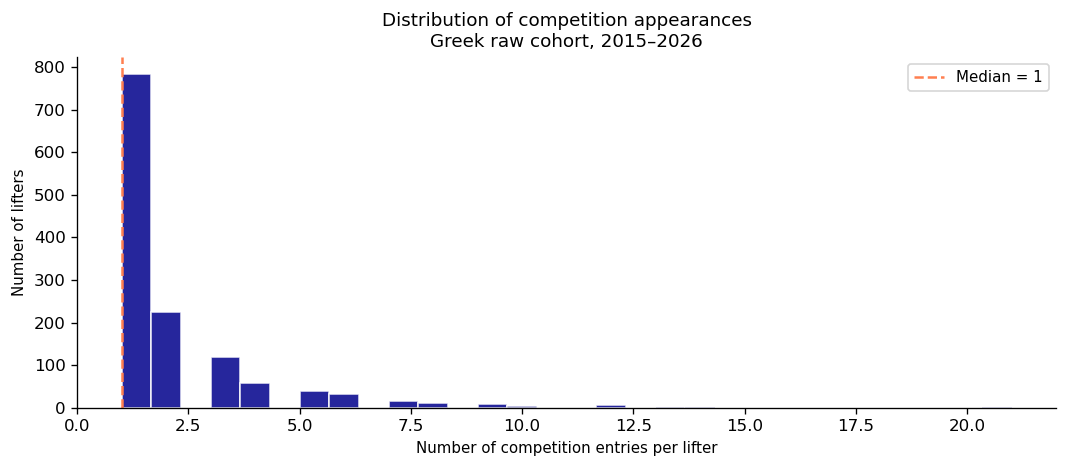

In [7]:
n_unique_lifters  = df['Name'].nunique()
entries_per_lifter = df.groupby('Name').size()

sep = '=' * 43

print(f"{sep}") 
print(f"Unique lifters in cohort:      {n_unique_lifters:,}")
print(f"Total competition entries:     {len(df):,}")
print(f"{sep}")
print()
print(f"{sep}")
print(f"\nEntries per lifter:")
print(f"  Mean:    {entries_per_lifter.mean():.1f}")
print(f"  Median:  {entries_per_lifter.median():.0f}")
print(f"  Min:     {entries_per_lifter.min()}")
print(f"  Max:     {entries_per_lifter.max()}")
print(f"{sep}") 
# Bin lifters by number of appearances to show the distribution shape
bins   = [1, 2, 5, 10, 20, np.inf]
labels = ['1', '2-4', '5-9', '10-19', '20+']

binned        = pd.cut(entries_per_lifter, bins=bins, labels=labels, right=False)
bin_counts    = binned.value_counts().sort_index()

print() 
print(f"{sep}") 
print(f"Lifters by number of appearances:")
for label, count in bin_counts.items():
    pct = count / n_unique_lifters * 100
    print(f"  {label:>5} appearances: {count:>4} lifters  ({pct:.1f}%)")
print(f"{sep}") 
print() 
# Plot: histogram of entries per lifter
fig, ax = plt.subplots(figsize=(9, 4))

ax.hist(entries_per_lifter, bins=30, color='darkblue',
        edgecolor='white', alpha=0.85)
ax.set_xlabel('Number of competition entries per lifter')
ax.set_ylabel('Number of lifters')
ax.set_title('Distribution of competition appearances\nGreek raw cohort, 2015–2026')

median_val = entries_per_lifter.median()
ax.axvline(median_val, color='coral', linewidth=1.5,
           linestyle='--', label=f'Median = {median_val:.0f}')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(plots_dir / 'lifter_appearances.png', bbox_inches='tight')
plt.show()

## Cell 7 —  Top lifters by appearance count

The top lifters by entry count are the most influential observations in the dataset. Knowing who they are helps assess whether the model
is dominated by a small group of very active competitors.

In [8]:
top_lifters = (
    df.groupby('Name')
    .size()
    .sort_values(ascending=False)
    .head(20)
    .reset_index()
)
top_lifters.columns = ['Name', 'n_entries']

print("Top 20 lifters by number of competition entries:")
top_lifters.index = top_lifters.index + 1
print(top_lifters.to_string()) 

Top 20 lifters by number of competition entries:
                         Name  n_entries
1              Marios Liatsis         21
2        Konstantinos Lazaris         14
3          Emmanouel Varveris         13
4       Konstantinos Barounis         12
5        Alexandros Sakarikas         12
6             Odysseas Markou         12
7       Panagiwtis Mpoldoglou         12
8         Dimitris Davazoglou         12
9                 Mary Tsimpi         12
10            Sofia Andreikou         10
11              Savvas Savvas         10
12        Panagiotis Perentis         10
13     Vasileios Karakatsanis          9
14  Alexandros-Ioannis Drosos          9
15     Despoina Charitopoulou          9
16  Konstantinos Konstantatos          9
17           Thomas Aggelakis          9
18        Nikolaos Kakaletris          9
19            Nikolaos Karras          9
20      Panagiotis Kachilelis          9


## Cell 8 - Federation and year breakdown 

Federation breakdown reveals which organizations dominate Greek powerlifting. Year distribution shows the growth of the sport and justifies the 2015 cutoff.

The SBD filter reshuffles the federation landscape significantly: HPF dominates (66% of entries) because it specialises in full-power meets, while ESDT — the largest federation in the unfiltered data — collapses to 11% since it primarily runs single-lift and push-pull events. Phase 2 note: the dummy reference category should be HPF, not ESDT.

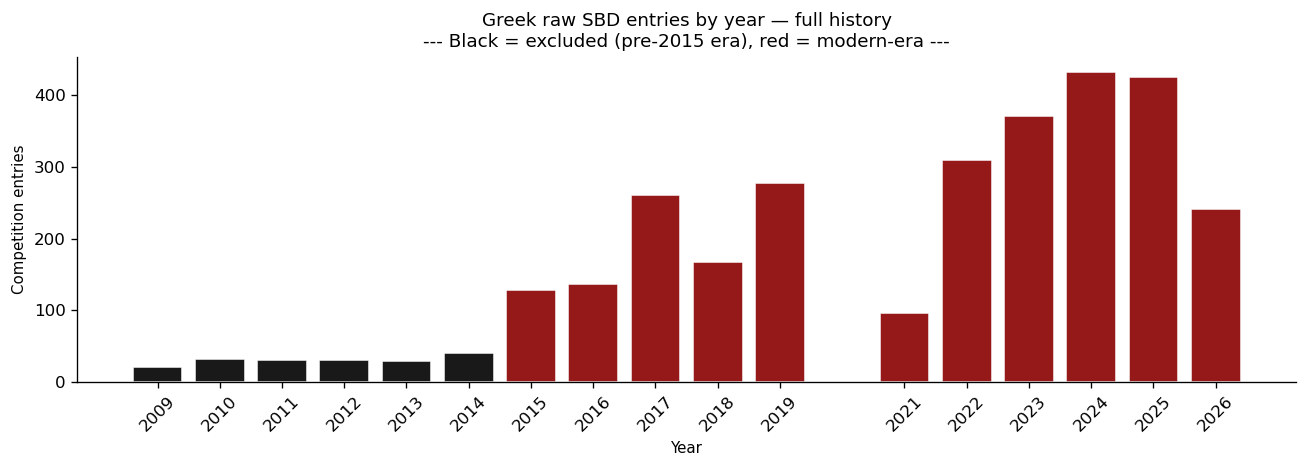

In [9]:
greek_sbd_raw = df_raw[
    (df_raw['Country'] == 'Greece') &
    (df_raw['Equipment'] == 'Raw') &
    (df_raw['Event'] == 'SBD')
].copy()
greek_sbd_raw['Year'] = pd.to_datetime(greek_sbd_raw['Date']).dt.year

year_counts = greek_sbd_raw['Year'].value_counts().sort_index()
colors      = ['black' if y < 2015 else 'darkred' for y in year_counts.index]

fig, ax = plt.subplots(figsize=(11, 4))
ax.bar(year_counts.index, year_counts.values, color=colors, edgecolor='white', alpha = 0.9)
ax.set_xlabel('Year')
ax.set_ylabel('Competition entries')
ax.set_title('Greek raw SBD entries by year — full history\n--- Black = excluded (pre-2015 era), red = modern-era ---')
ax.set_xticks(year_counts.index)
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig(plots_dir / 'year_cutoff_justification.png', bbox_inches='tight')
plt.show()

============= Federation Breakdown =============
Federation
HPF           1736
GPL            417
ESDT           292
EPF             66
IPL             49
GPA             33
IPF             20
WP               9
WRPF-Spain       4
PLSS             4
ABS              3
KNKF-SP          3
PLTRAW           2
PLU              2
CyprusPF         2
WRPF-DE          1
WRPF-UK          1
WRPF             1
Germany-UA       1
============= Parent Federation Breakdown =============
ParentFederation
IPF     1831
IPL      466
WP       301
GPA       33
WRPF       7
============= Entries by Year =============
Year
2015    120
2016    118
2017    240
2018    158
2019    246
2021     87
2022    285
2023    352
2024    407
2025    400
2026    233


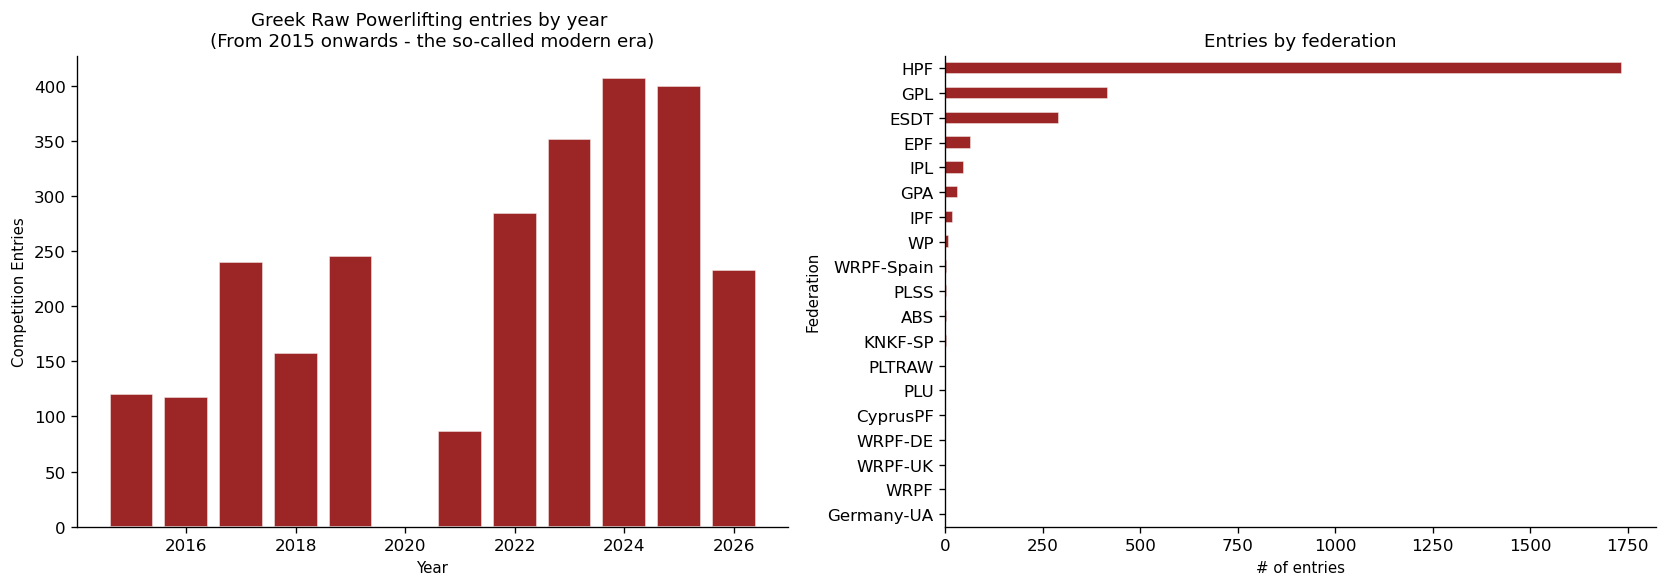

In [10]:
sep = '=' * 13  

print(sep, 'Federation Breakdown', sep)
fed_counts = df['Federation'].value_counts()
print(fed_counts.to_string())

print(sep, 'Parent Federation Breakdown', sep) 
parent_fed_counts = df['ParentFederation'].value_counts() 
print(parent_fed_counts.to_string())

print(sep, 'Entries by Year', sep) 
year_counts = df['Year'].value_counts().sort_index() 
print(year_counts.to_string())

print(4 * sep)

fig, axes = plt.subplots(1, 2, figsize = (14, 5))

# Left: bar chart of entries per year
year_index  = year_counts.index.tolist()
year_values = year_counts.values.tolist()

axes[0].bar(year_index, year_values, color = 'darkred', edgecolor = 'white', alpha = 0.85)
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Competition Entries')
axes[0].set_title('Greek Raw Powerlifting entries by year \n(From 2015 onwards - the so-called modern era)')

# Right: federation breakdown horizontally 
fed_counts.plot(kind = 'barh', ax = axes[1], color = 'darkred', edgecolor = 'white', alpha = 0.85)
axes[1].set_xlabel('# of entries')
axes[1].set_ylabel('Federation')
axes[1].set_title('Entries by federation')
axes[1].invert_yaxis() 

plt.tight_layout() 
plt.savefig(plots_dir / 'federation_year_breakdown.png', bbox_inches='tight')
plt.show() 

## Cell 9 — Cohort breakdown by sex and weight class

In [11]:
sep = '=' * 13  

print(sep, 'By Sex', sep)
sex_counts = df['Sex'].value_counts()
print(sex_counts.to_string())

print(sep, 'By WeightClass (in Kg)', sep)
weight_counts = df['WeightClassKg'].value_counts().sort_index() 
print(weight_counts.to_string())

print(sep, 'Sex × WeightClassKg', sep) 
crosstab = pd.crosstab(df['Sex'], df['WeightClassKg'])
print(crosstab.to_string()) 

============= By Sex =============
Sex
M    2109
F     537
============= By WeightClass (in Kg) =============
WeightClassKg
100     110
100+      1
105     227
110      58
120     102
120+     76
125      37
140       9
140+      9
145       1
43        2
47        7
48        6
52       57
53       10
56       35
57       66
58        5
59       15
60       33
62        1
63       84
64        2
66      103
67.5     81
69       54
72       25
74      214
75      102
76       43
77        4
82.5    138
83      369
84       17
84+      15
85        3
90      143
90+       1
93      371
94        3
============= Sex × WeightClassKg =============
WeightClassKg  100  100+  105  110  120  120+  125  140  140+  145  43  47  48  52  53  56  57  58  59  60  62  63  64   66  67.5  69  72   74  75  76  77  82.5   83  84  84+  85   90  90+   93  94
Sex                                                                                                                                                   

## Cell 10 — Statistical summary of filtered cohort

Statistical summary of the key numerical columns after all filtering. This is the first meaningful summary — earlier describe() on df_raw
was dominated by non-Greek entries and is not informative for modeling.

In [12]:
cols_of_interest = [
    'Best3SquatKg', 'Best3BenchKg', 'Best3DeadliftKg', 'TotalKg',
    'BodyweightKg', 'Age', 'Dots', 'Wilks', 'Goodlift'
]

summary = df[cols_of_interest].describe().T 
print(summary) 

                  count   mean    std    min    25%    50%    75%    max
Best3SquatKg    2606.00 174.12  56.22  20.00 132.50 175.00 210.00 380.00
Best3BenchKg    2604.00 112.99  39.34  15.00  85.00 117.50 140.00 230.00
Best3DeadliftKg 2605.00 203.12  56.42  20.00 160.50 207.50 242.50 375.00
TotalKg         2646.00 489.62 145.96 110.00 382.50 500.00 589.38 907.50
BodyweightKg    2645.00  83.90  19.51  30.00  71.40  82.05  92.50 212.10
Age             1828.00  25.96   7.92  10.00  21.00  24.00  29.00  74.50
Dots            2645.00 348.32  67.79 110.10 304.07 347.25 392.64 573.92
Wilks           2645.00 346.31  67.29 107.63 303.04 345.25 390.40 566.69
Goodlift        2643.00  71.04  13.80  23.06  61.98  70.97  80.19 118.00


## Cell 11 — Best3* semantic verification

Each Best3* column should equal the maximum of the three individual attempt columns for that lift (ignoring failed or missing attempts).
We verify this on a random sample to confirm internal consistency.

Mismatches usually mean the federation reported only the best lift, without individual attempts — not a data error, just incomplete reporting.

In [13]:
def verify_best3(df, attempt_cols, best_col, n_sample=300):
    # Keep only rows where the best column is not missing
    available = df[attempt_cols + [best_col]].dropna(subset=[best_col]).copy()
    sample    = available.sample(min(n_sample, len(available)), random_state=42)

    # Treat non-positive values as missing — failed attempts are negative
    attempts_positive = sample[attempt_cols].apply(
        lambda col: col.where(col > 0)
    )

    # The computed best should be the maximum across the three attempts
    computed_best = attempts_positive.max(axis=1)

    # Allow small tolerance for floating point differences
    matches    = np.isclose(computed_best, sample[best_col], atol=0.01)
    mismatches = sample[matches == False]

    return len(sample), matches.sum(), (matches == False).sum(), mismatches


checks = [
    (['Squat1Kg',    'Squat2Kg',    'Squat3Kg'],    'Best3SquatKg'),
    (['Bench1Kg',    'Bench2Kg',    'Bench3Kg'],    'Best3BenchKg'),
    (['Deadlift1Kg', 'Deadlift2Kg', 'Deadlift3Kg'], 'Best3DeadliftKg'),
]

for attempt_cols, best_col in checks:
    n_checked, n_matched, n_mismatched, bad_rows = verify_best3(
        df, attempt_cols, best_col
    )

    print(f"{best_col}")
    print(f"  Checked: {n_checked}  |  Matched: {n_matched}  |  Mismatched: {n_mismatched}")

    if n_mismatched > 0:
        print("  Sample mismatches (federations reporting best only):")
        print(bad_rows[attempt_cols + [best_col]].head(3).to_string())
    print()

Best3SquatKg
  Checked: 300  |  Matched: 287  |  Mismatched: 13
  Sample mismatches (federations reporting best only):
         Squat1Kg  Squat2Kg  Squat3Kg  Best3SquatKg
2742223       NaN       NaN       NaN        130.00
2742374       NaN       NaN       NaN        126.00
2742376       NaN       NaN       NaN        170.00

Best3BenchKg
  Checked: 300  |  Matched: 285  |  Mismatched: 15
  Sample mismatches (federations reporting best only):
         Bench1Kg  Bench2Kg  Bench3Kg  Best3BenchKg
2742223       NaN       NaN       NaN         90.00
2739191       NaN       NaN       NaN        122.50
2742374       NaN       NaN       NaN        104.00

Best3DeadliftKg
  Checked: 300  |  Matched: 287  |  Mismatched: 13
  Sample mismatches (federations reporting best only):
         Deadlift1Kg  Deadlift2Kg  Deadlift3Kg  Best3DeadliftKg
2742223          NaN          NaN          NaN           170.00
2742654          NaN          NaN          NaN           215.00
2742374          NaN          

## Cell 12 — Attempt column missingness

Individual attempt columns are often missing when a federation reports only the best lift rather than all three attempts.
This does not affect our targets (Best3*) but matters if we later want to use attempt progression as a feature in Phase 2.

In [14]:
sep = '=' * 13

attempt_cols_all = [
    'Squat1Kg',    'Squat2Kg',    'Squat3Kg',
    'Bench1Kg',    'Bench2Kg',    'Bench3Kg',
    'Deadlift1Kg', 'Deadlift2Kg', 'Deadlift3Kg'
]

print(sep, 'Attempt column missingness', sep)
for col in attempt_cols_all:
    n_missing = df[col].isna().sum()
    pct       = n_missing / len(df) * 100
    print(f"  {col:<15} {n_missing:>5} missing  ({pct:.1f}%)") 

============= Attempt column missingness =============
  Squat1Kg          179 missing  (6.8%)
  Squat2Kg          205 missing  (7.7%)
  Squat3Kg          284 missing  (10.7%)
  Bench1Kg          179 missing  (6.8%)
  Bench2Kg          193 missing  (7.3%)
  Bench3Kg          310 missing  (11.7%)
  Deadlift1Kg       177 missing  (6.7%)
  Deadlift2Kg       194 missing  (7.3%)
  Deadlift3Kg       294 missing  (11.1%)


## Cell 13 — Target and feature missingness audit 

We separate targets, features, and scoring metrics into three groups. Dots, Wilks, and Goodlift are flagged explicitly as derived columns
to remind us not to use them as features in Phase 2.

In [15]:
sep = '=' * 13

target_cols  = ['Best3SquatKg', 'Best3BenchKg', 'Best3DeadliftKg', 'TotalKg']
feature_cols = ['BodyweightKg', 'Age', 'Sex', 'WeightClassKg', 'Federation', 'Tested']
score_cols   = ['Dots', 'Wilks', 'Goodlift']

print(sep, 'Target missingness', sep)
for col in target_cols:
    n_missing = df[col].isna().sum()
    pct       = n_missing / len(df) * 100
    print(f"  {col:<22} {n_missing:>5} missing  ({pct:.1f}%)")

print(sep, 'Feature missingness', sep) 
for col in feature_cols:
    n_missing = df[col].isna().sum()
    pct       = n_missing / len(df) * 100
    print(f"  {col:<22} {n_missing:>5} missing  ({pct:.1f}%)")

print(sep, 'Scoring metrics (derived from target)', sep) 
for col in score_cols:
    n_missing = df[col].isna().sum()
    pct       = n_missing / len(df) * 100
    print(f"  {col:<22} {n_missing:>5} missing  ({pct:.1f}%)")

print(4 * sep )
print('  Note: Dots, Wilks, and Goodlift are computed from')
print('  TotalKg and BodyweightKg. Using them as features')
print('  would cause target leakage — excluded from modeling.')
print(4 * sep ) 

============= Target missingness =============
  Best3SquatKg              40 missing  (1.5%)
  Best3BenchKg              42 missing  (1.6%)
  Best3DeadliftKg           41 missing  (1.5%)
  TotalKg                    0 missing  (0.0%)
============= Feature missingness =============
  BodyweightKg               1 missing  (0.0%)
  Age                      818 missing  (30.9%)
  Sex                        0 missing  (0.0%)
  WeightClassKg              7 missing  (0.3%)
  Federation                 0 missing  (0.0%)
  Tested                   668 missing  (25.2%)
============= Scoring metrics (derived from target) =============
  Dots                       1 missing  (0.0%)
  Wilks                      1 missing  (0.0%)
  Goodlift                   3 missing  (0.1%)
  Note: Dots, Wilks, and Goodlift are computed from
  TotalKg and BodyweightKg. Using them as features
  would cause target leakage — excluded from modeling.


## Cell 14 — Missingness heatmap

Visual representation of the missingness structure. Red cells are missing, gray cells are present. Horizontal red bands indicate a column that is mostly missing. Vertical red stripes indicate specific rows missing many values.

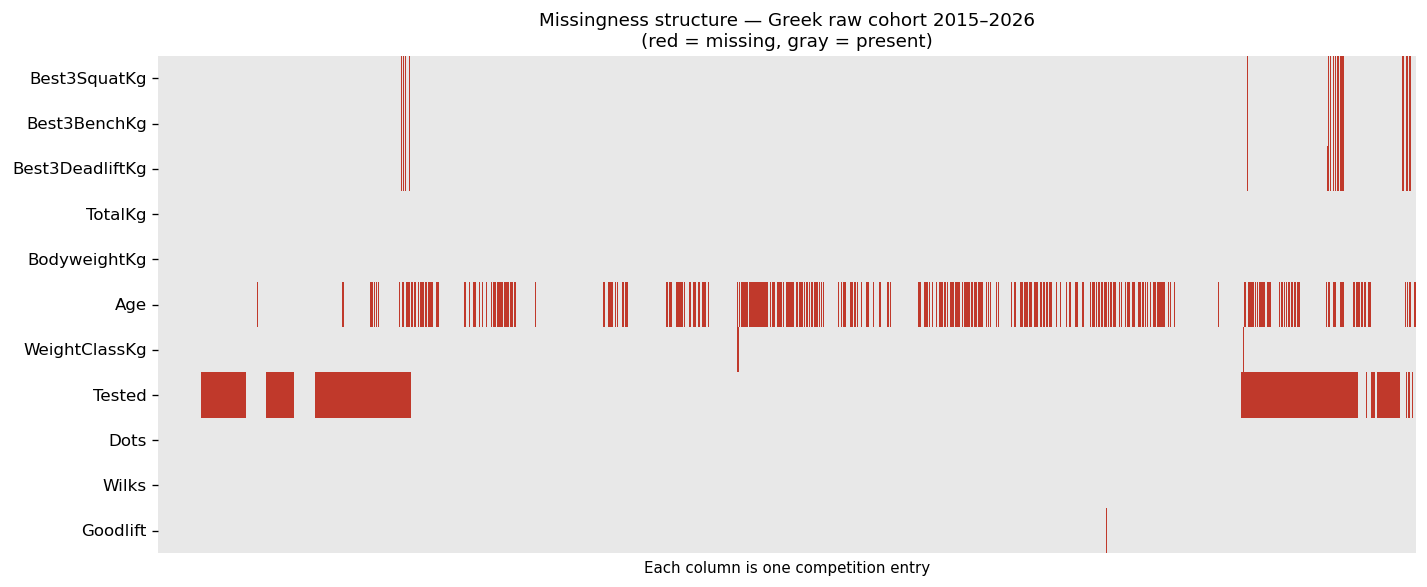

In [16]:
cols_for_heatmap = [
    'Best3SquatKg', 'Best3BenchKg', 'Best3DeadliftKg', 'TotalKg',
    'BodyweightKg', 'Age', 'WeightClassKg', 'Tested',
    'Dots', 'Wilks', 'Goodlift'
]

missing_matrix = df[cols_for_heatmap].isna().astype(int)

fig, ax = plt.subplots(figsize=(12, 5))

sns.heatmap(
    missing_matrix.T,
    cbar        = False,
    cmap        = ['#e8e8e8', '#c0392b'],
    ax          = ax,
    yticklabels = cols_for_heatmap,
    xticklabels = False
)

ax.set_xlabel('Each column is one competition entry', fontsize=9)
ax.set_title(
    'Missingness structure — Greek raw cohort 2015–2026\n'
    '(red = missing, gray = present)',
    fontsize=11
)

plt.tight_layout()
plt.savefig(plots_dir / 'missingness_heatmap.png', bbox_inches='tight')
plt.show()

## Cell 15 — Skewness, kurtosis, and Q-Q plots

We check whether the four target distributions are approximately normal. Skewness > 1.0 in absolute value typically warrants a log transformation. The Q-Q plot shows where the distribution departs from normality — heavy tails appear as points curving away from the diagonal at the extremes. (excess kurtosis; normal distribution = 0) 

Target                   Skewness   Kurtosis   Suggestion
──────────────────────────────────────────────────────────────
Best3SquatKg                0.187     -0.142   ok as-is
Best3BenchKg               -0.040     -0.430   ok as-is
Best3DeadliftKg            -0.130     -0.387   ok as-is
TotalKg                    -0.041     -0.464   ok as-is


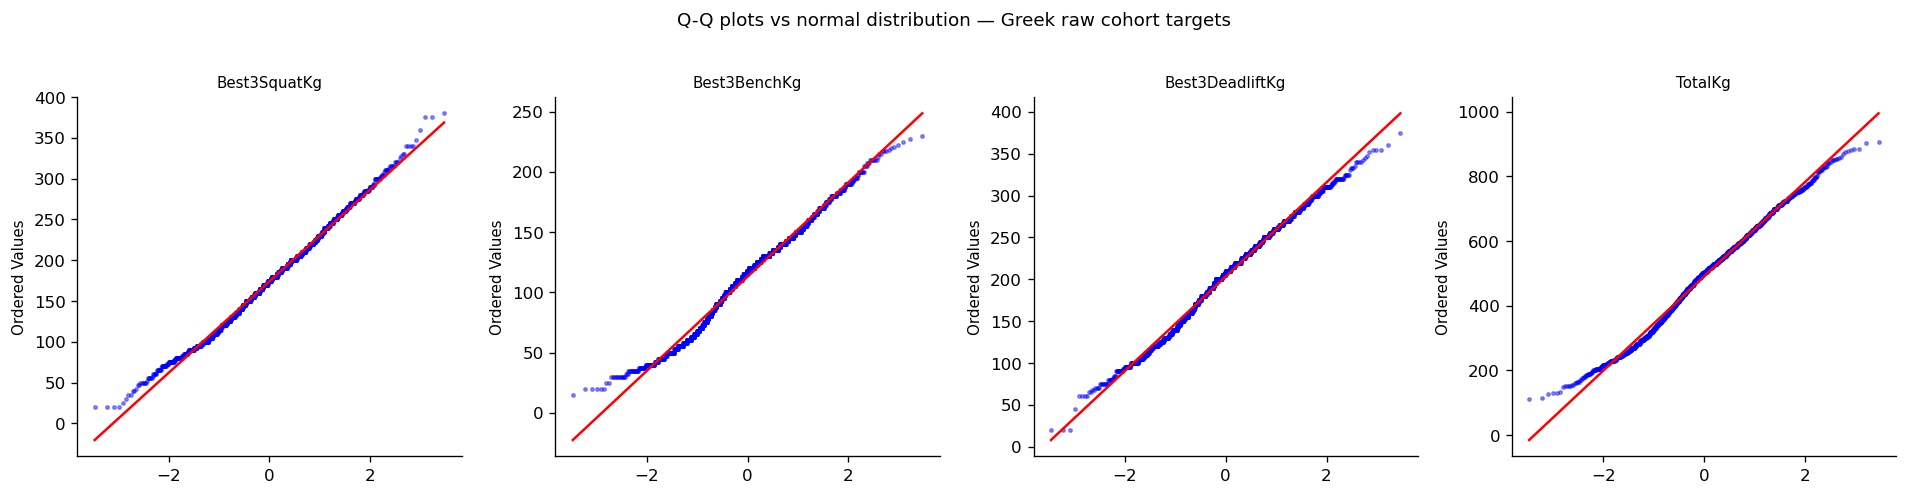

============= TotalKg skewness by sex =============
  M: skewness = 0.115  (n=2,109)
  F: skewness = 0.274  (n=537)


In [17]:
targets = ['Best3SquatKg', 'Best3BenchKg', 'Best3DeadliftKg', 'TotalKg']

print(f"{'Target':<22} {'Skewness':>10} {'Kurtosis':>10}   {'Suggestion'}")
print('─' * 62)

for target in targets:
    data       = df[target].dropna()
    skewness   = data.skew()
    kurtosis   = data.kurtosis()
    suggestion = 'consider log transform' if abs(skewness) > 1.0 else 'ok as-is'
    print(f"{target:<22} {skewness:>10.3f} {kurtosis:>10.3f}   {suggestion}")

# Q-Q plots
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for ax, target in zip(axes, targets):
    data = df[target].dropna()
    scipy_stats.probplot(data, dist='norm', plot=ax)
    ax.set_title(target, fontsize=9)
    ax.set_xlabel('')
    ax.get_lines()[0].set(markersize=2, alpha=0.4)

plt.suptitle(
    'Q-Q plots vs normal distribution — Greek raw cohort targets',
    fontsize=11, y=1.02
)
plt.tight_layout()
plt.savefig(plots_dir / 'qq_plots_targets.png', bbox_inches='tight')
plt.show()

sep = '=' * 13

# Check skewness split by sex
# Symmetry holds within each sex too
print(sep, 'TotalKg skewness by sex', sep)
for sex in ['M', 'F']:
    subset   = df[df['Sex'] == sex]['TotalKg'].dropna()
    skewness = subset.skew()
    print(f"  {sex}: skewness = {skewness:.3f}  (n={len(subset):,})")

print(4 * sep)

## Cell 16 — Log-transform evaluation with KDE

For each target we show the raw and log-transformed distributions side by side with KDE curves overlaid on histograms.
```density = True``` normalizes the histogram so the KDE and bars are on the same scale and directly comparable.

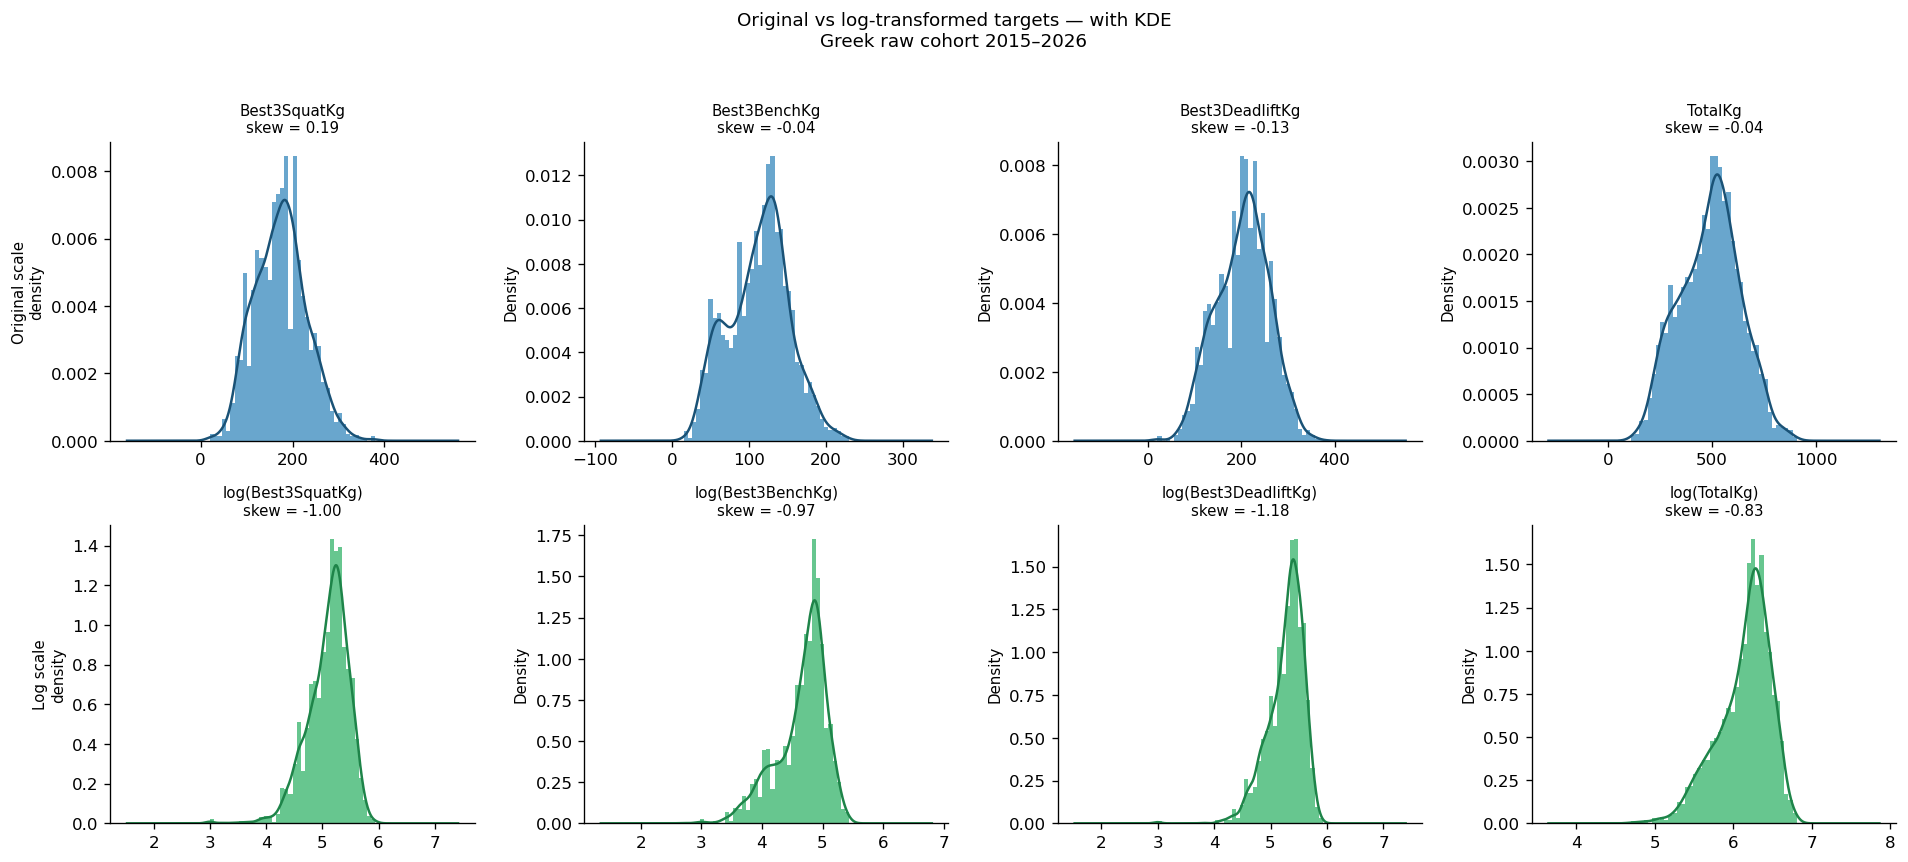

In [18]:
targets = ['Best3SquatKg', 'Best3BenchKg', 'Best3DeadliftKg', 'TotalKg']

fig, axes = plt.subplots(2, 4, figsize=(16, 7))

for i, target in enumerate(targets):
    raw_data = df[target].dropna()
    raw_data = raw_data[raw_data > 0]
    log_data = np.log(raw_data)

    raw_skew = raw_data.skew()
    log_skew = log_data.skew()

    # Top row: raw scale
    axes[0, i].hist(raw_data, bins=40, color='#2980b9',
                    edgecolor='none', alpha=0.7, density=True)
    raw_data.plot.kde(ax=axes[0, i], color='#1a5276', linewidth=1.5)
    axes[0, i].set_title(f"{target}\nskew = {raw_skew:.2f}", fontsize=9)

    # Bottom row: log scale
    axes[1, i].hist(log_data, bins=40, color='#27ae60',
                    edgecolor='none', alpha=0.7, density=True)
    log_data.plot.kde(ax=axes[1, i], color='#1e8449', linewidth=1.5)
    axes[1, i].set_title(f"log({target})\nskew = {log_skew:.2f}", fontsize=9)

axes[0, 0].set_ylabel('Original scale\ndensity', fontsize=9)
axes[1, 0].set_ylabel('Log scale\ndensity', fontsize=9)

plt.suptitle(
    'Original vs log-transformed targets — with KDE\nGreek raw cohort 2015–2026',
    fontsize=11, y=1.02
)
plt.tight_layout()
plt.savefig(plots_dir / 'log_transform_evaluation.png', bbox_inches='tight')
plt.show()
# No transformation warranted; log would introduce left-skew

## Cell 17 — Correlation analysis: features only

Pearson correlation between the numerical features and targets. Dots, Wilks, and Goodlift are excluded — they are derived from TotalKg and would produce artificially high correlations.

============= Top correlates with TotalKg =============
Best3SquatKg      0.97
Best3DeadliftKg   0.97
Best3BenchKg      0.94
BodyweightKg      0.66
Age               0.01


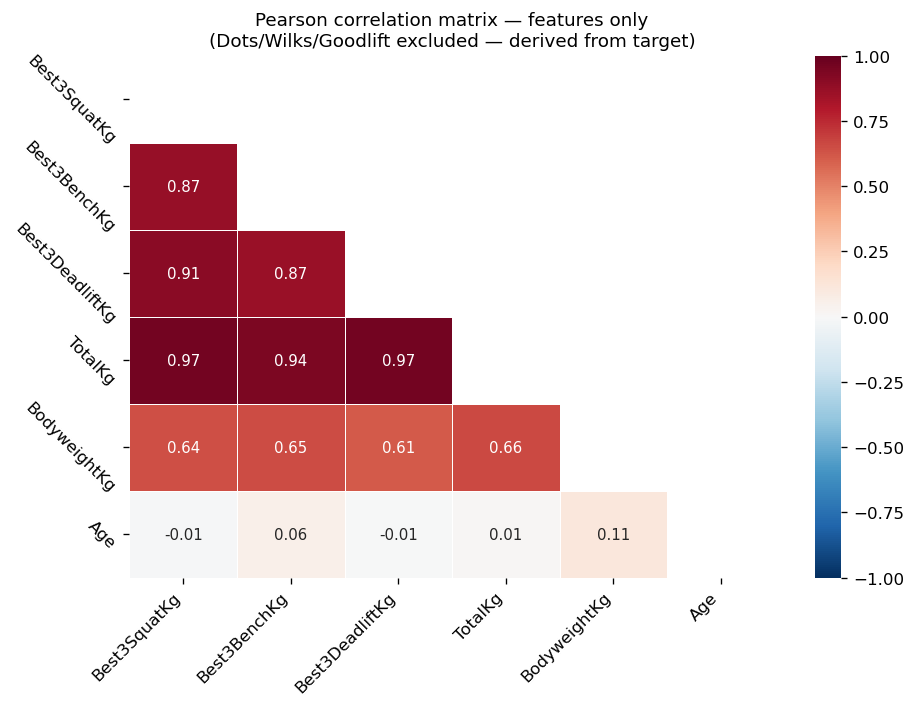

In [19]:
sep = '=' * 13

feature_numeric_cols = [
    'Best3SquatKg', 'Best3BenchKg', 'Best3DeadliftKg', 'TotalKg',
    'BodyweightKg', 'Age'
]

corr_matrix = df[feature_numeric_cols].corr()

print(sep, 'Top correlates with TotalKg', sep)
total_corr = corr_matrix['TotalKg'].drop('TotalKg')
total_corr = total_corr.abs().sort_values(ascending=False)
print(total_corr.round(3).to_string())

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

fig, ax = plt.subplots(figsize=(8, 6))

sns.heatmap(
    corr_matrix,
    mask       = mask,
    annot      = True,
    fmt        = '.2f',
    cmap       = 'RdBu_r',
    center     = 0,
    vmin       = -1,
    vmax       = 1,
    ax         = ax,
    linewidths = 0.5,
    annot_kws  = {'size': 9}
)

ax.set_title(
    'Pearson correlation matrix — features only\n'
    '(Dots/Wilks/Goodlift excluded — derived from target)',
    fontsize=11
)

# Fix y-axis label rotation 
ax.set_yticklabels(ax.get_yticklabels(), rotation = -45)

# Fix x-axis label rotation 
ax.set_xticklabels(ax.get_xticklabels(), rotation = 45, ha='right')

plt.tight_layout()
plt.savefig(plots_dir / 'correlation_heatmap_features.png', bbox_inches='tight')
plt.show()

## Cell 18 — Scoring metrics: leakage confirmation

================= Correlation of scoring metrics with TotalKg =================
BodyweightKg   0.66
Dots           0.78
Wilks          0.77
Goodlift       0.78

Dots, Wilks, and Goodlift are deterministic functions of TotalKg and BodyweightKg.
They are the target, repackaged — so they leak by construction.


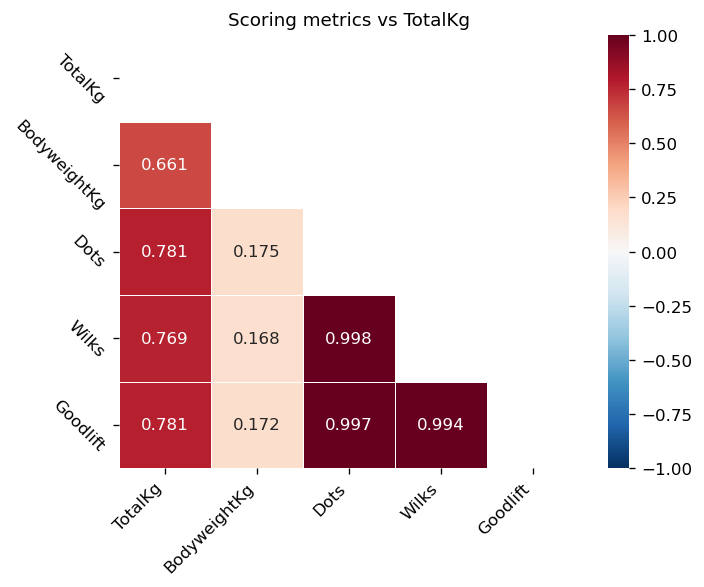

In [20]:
sep = '=' * 17

score_cols_check = ['TotalKg', 'BodyweightKg', 'Dots', 'Wilks', 'Goodlift']

score_corr = df[score_cols_check].corr()

print(sep, 'Correlation of scoring metrics with TotalKg', sep)
score_with_total = score_corr['TotalKg'].drop('TotalKg')
print(score_with_total.round(4).to_string())
print()
print('Dots, Wilks, and Goodlift are deterministic functions of TotalKg and BodyweightKg.')
print('They are the target, repackaged — so they leak by construction.')

mask_score = np.triu(np.ones_like(score_corr, dtype=bool))

fig, ax = plt.subplots(figsize=(6, 5))

sns.heatmap(
    score_corr,
    mask       = mask_score,
    annot      = True,
    fmt        = '.3f',
    cmap       = 'RdBu_r',
    center     = 0,
    vmin       = -1,
    vmax       = 1,
    ax         = ax,
    linewidths = 0.5,
    annot_kws  = {'size': 10}
)

ax.set_title(
    'Scoring metrics vs TotalKg',
    fontsize=11
)

# Fix y-axis label rotation  
ax.set_yticklabels(ax.get_yticklabels(), rotation = -45)

# Fix x-axis label rotation  
ax.set_xticklabels(ax.get_xticklabels(), rotation = 45, ha='right')

plt.tight_layout()
plt.savefig(plots_dir / 'correlation_scoring_leakage.png', bbox_inches='tight')
plt.show()

## Cell 19 — Comparative summary statistics 

Descriptive statistics for each group side by side. We look at the four targets separately for male and female lifters to avoid the sex mixing artifact we identified in Cell 16.

In [21]:
sep = '=' * 17

# Combine all three groups into one dataframe for plotting
df_greece_labelled = df.copy()
df_greece_labelled['Group'] = 'Greece'
print(f"{'Greece':<30} {len(df_greece_labelled):>7,} entries  "
      f"| {df_greece_labelled['Name'].nunique():>5} unique lifters")

df_comparison = pd.concat(
    [df_greece_labelled, df_south_a, df_balkans_a],
    ignore_index=True
)

print(f"\nCombined comparison dataframe: {len(df_comparison):,} rows")

targets      = ['Best3SquatKg', 'Best3BenchKg', 'Best3DeadliftKg', 'TotalKg']
groups       = ['Greece', 'Southern Europe', 'Balkans (excl. Greece)']
sexes        = ['M', 'F']
sex_labels   = {'M': 'Male', 'F': 'Female'}

for sex in sexes:
    print(f"{5 * sep}")
    print(f"  {sex_labels[sex]} lifters")
    print(f"{5 * sep}")

    for target in targets:
        print(f"\n  {target}")
        print(f"  {'Group':<28} {'Mean':>8} {'Median':>8} {'Std':>8} {'n':>6}")
        print(f"  {'─'*56}")

        for group in groups:
            subset = df_comparison[
                (df_comparison['Group'] == group) &
                (df_comparison['Sex']   == sex)
            ][target].dropna()

            if len(subset) == 0:
                print(f"  {group:<28} {'no data':>8}")
                continue

            mean   = subset.mean()
            median = subset.median()
            std    = subset.std()
            n      = len(subset)

            print(f"  {group:<28} {mean:>8.1f} {median:>8.1f} {std:>8.1f} {n:>6,}")

Greece                           2,646 entries  |  1307 unique lifters

Combined comparison dataframe: 43,105 rows
  Male lifters

  Best3SquatKg
  Group                            Mean   Median      Std      n
  ────────────────────────────────────────────────────────
  Greece                          191.0    190.0     48.8  2,071
  Southern Europe                 202.2    200.0     41.8 21,757
  Balkans (excl. Greece)          194.2    192.5     47.7  7,033

  Best3BenchKg
  Group                            Mean   Median      Std      n
  ────────────────────────────────────────────────────────
  Greece                          127.0    127.5     30.4  2,069
  Southern Europe                 128.0    125.0     27.0 21,756
  Balkans (excl. Greece)          129.3    127.5     31.7  7,034

  Best3DeadliftKg
  Group                            Mean   Median      Std      n
  ────────────────────────────────────────────────────────
  Greece                          221.9    220.0     45.6

## Cell 20 — Comparative KDE plots: all four targets

KDE curves for all four targets across the three groups, split by sex. Layout: 2 rows (M/F) × 4 columns (targets). Each panel shows three overlapping KDE curves — one per group.
Overlapping curves reveal whether distributions are similar or whether one group is systematically stronger or weaker.

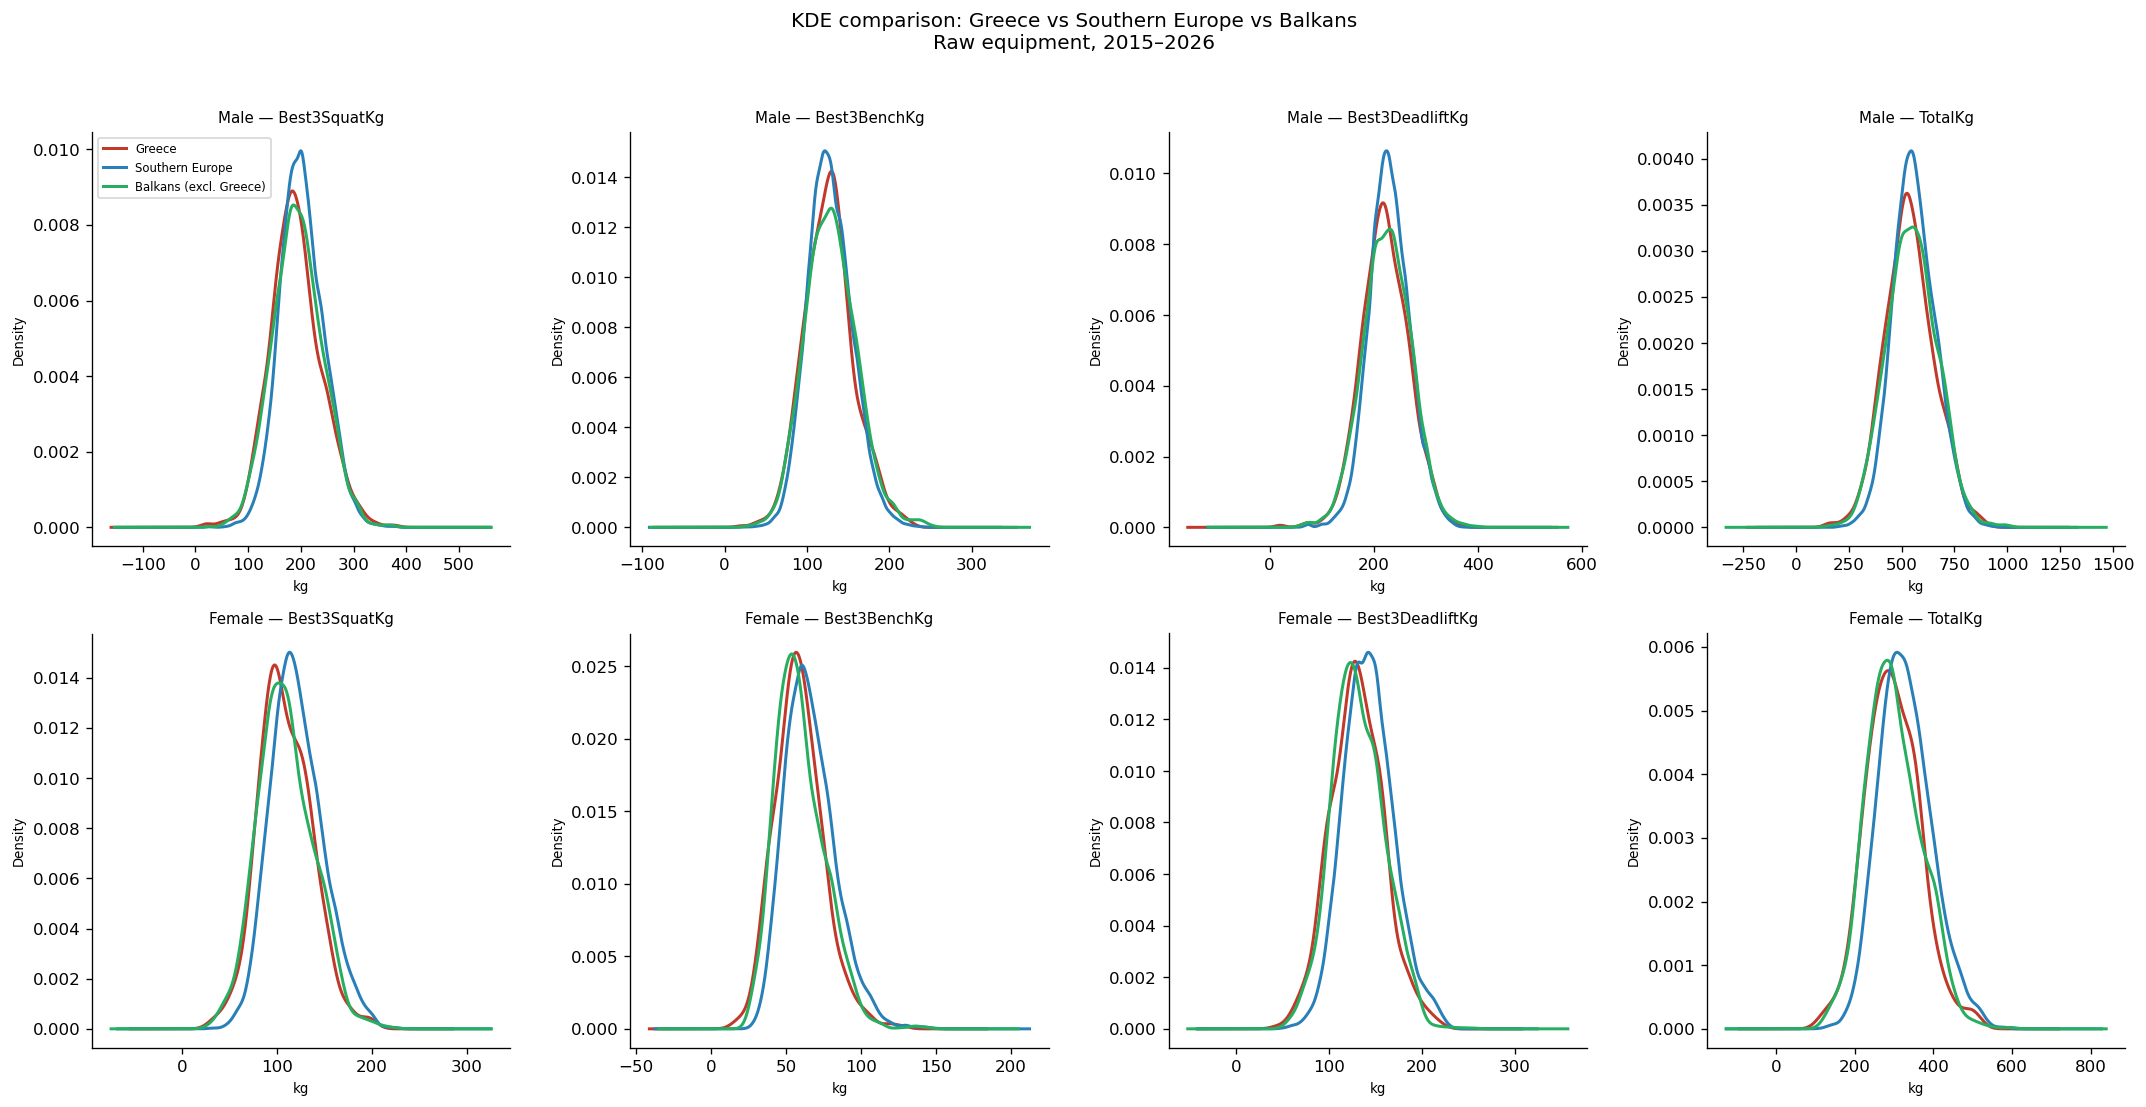

In [22]:
group_colors = {
    'Greece':                 '#c0392b',
    'Southern Europe':        '#2980b9',
    'Balkans (excl. Greece)': '#27ae60'
}

fig, axes = plt.subplots(2, 4, figsize=(18, 9))

for row_idx, sex in enumerate(['M', 'F']):
    for col_idx, target in enumerate(targets):
        ax = axes[row_idx, col_idx]

        for group in groups:
            subset = df_comparison[
                (df_comparison['Group'] == group) &
                (df_comparison['Sex']   == sex)
            ][target].dropna()

            if len(subset) < 10:
                continue

            subset.plot.kde(
                ax        = ax,
                color     = group_colors[group],
                linewidth = 1.8,
                label     = group
            )

        sex_label = 'Male' if sex == 'M' else 'Female'
        ax.set_title(f"{sex_label} — {target}", fontsize=9)
        ax.set_xlabel('kg', fontsize=8)
        ax.set_ylabel('Density', fontsize=8)

        # Only show legend on the first panel to avoid repetition
        if row_idx == 0 and col_idx == 0:
            ax.legend(fontsize=7, loc='upper left')

plt.suptitle(
    'KDE comparison: Greece vs Southern Europe vs Balkans\n'
    'Raw equipment, 2015–2026',
    fontsize=12, y=1.02
)
plt.tight_layout()
plt.savefig(plots_dir / 'comparative_kde_all_targets.png', bbox_inches='tight')
plt.show()

# PHASE 2 - FEATURE ENGINEERING AND PREPROCESSING

## Cell 21 — Compute the baselines

We compute the:

1. predict-the-mean RMSE
2. per-sex-mean RMSE
3. per-sex bodyweight linear regression RMSE on TotalKg
  
Three numbers stored as constants — the floors every later model has to beat.

In [23]:
#
# Overall baseline/Predict-the-mean RMSE 
mean_overall = df['TotalKg'].mean() 
mean_RMSE = calculate_rmse(df["TotalKg"], mean_overall)
print(f"The overall mean is given by:          {mean_overall}", 
      f"The predict-the-mean RMSE is given by: {mean_RMSE}", 
        sep='\n')
print('=' * 63)
# Stratified mean baseline/Per-sex-mean RMSE 
mean_per_sex = df.groupby('Sex')['TotalKg'].transform('mean')
mean_per_sex_RMSE = calculate_rmse(df["TotalKg"], mean_per_sex)
mean_per_sex_display = df.groupby('Sex')['TotalKg'].mean() 
print(f"The per-sex mean is given by:          {mean_per_sex_display}", 
      f"The per-sex-mean RMSE is given by:     {mean_per_sex_RMSE}", 
        sep='\n')
# 
def predict_sex_group_linear_regression(group):
    # drop rows where either feature or target is missing
    # one missing BodyweightKg row in the cohort would otherwise
    # cause np.polyfit's SVD solver to fail
    clean = group[['BodyweightKg', 'TotalKg']].dropna()
    # fit the polynomial (slope and intercept)
    coefficients     = np.polyfit(clean['BodyweightKg'], clean['TotalKg'], deg=1)
    # predict on the full group — the one missing row gets NaN automatically
    y_predictions    = np.polyval(coefficients, group['BodyweightKg'])
    y_predictions_series = pd.Series(y_predictions, index=group.index)
    return y_predictions_series
print('=' * 63)
predictions = (df.groupby('Sex', group_keys = False).apply(predict_sex_group_linear_regression, include_groups=False))
per_sex_linear_regression_RMSE = calculate_rmse(df["TotalKg"], predictions)
print(f"The per-sex-linear regression RMSE is given by:     {per_sex_linear_regression_RMSE}")

The overall mean is given by:          489.6218820861678
The predict-the-mean RMSE is given by: 145.93591978823997
The per-sex mean is given by:          Sex
F   297.48
M   538.55
Name: TotalKg, dtype: float64
The per-sex-mean RMSE is given by:     109.07227657452074
The per-sex-linear regression RMSE is given by:     94.42973447054979


## Cell 22 — Recode Tested

Tested encodes whether the competition was drug-tested. The raw column contains'Yes' or NaN; we recode to a binary integer.

1. Yes means tested, which maps to 1.
2. NaN means untested, which maps to 0.

In [24]:
sep = '=' * 13 
# Tested encodes whether the competition was drug-tested, at least in paperwork 
df['Tested'] = df['Tested'].map({'Yes': 1}).fillna(0).astype(int)
print(sep, 'Tested value counting after recoding', sep)
print(df['Tested'].value_counts().to_string())

============= Tested value counting after recoding =============
Tested
1    1978
0     668


## Cell 23 — Federation grouping

We group federations into tiers to avoid sparse dummy columns.
Rule: federations with ≥100 entries in the SBD cohort become named groups (HPF, GPL, ESDT); everything else gets grouped together under the same umbrella term; Federation_Other. 
We define the HPF as the implicit reference, since it is thelargest cohort and hence will provide us with the most stable baseline; dummy coefficients then read as deviation from HPF. 

In [25]:
sep = '=' * 13 
print(sep, 'Federation counts in Greek raw cohort',sep)
fed_counts = df['Federation'].value_counts()
print(fed_counts.to_string())
print(6 * sep)
#
def assign_federation_groups(federation_name): 
    major_feds = ['HPF', 'GPL', 'ESDT'] 

    if federation_name in major_feds: 
        return federation_name 
    else: 
        return 'Other Federations'

df['FederationGroup'] = df['Federation'].apply(assign_federation_groups) 
print(sep, 'Federation Groups counting', sep) 
print(df['FederationGroup'].value_counts().to_string())

============= Federation counts in Greek raw cohort =============
Federation
HPF           1736
GPL            417
ESDT           292
EPF             66
IPL             49
GPA             33
IPF             20
WP               9
WRPF-Spain       4
PLSS             4
ABS              3
KNKF-SP          3
PLTRAW           2
PLU              2
CyprusPF         2
WRPF-DE          1
WRPF-UK          1
WRPF             1
Germany-UA       1
============= Federation Groups counting =============
FederationGroup
HPF                  1736
GPL                   417
ESDT                  292
Other Federations     201


## Cell 24 — Parse WeightClassKg into a numerical ordinal

WeightClassKg is stored as a string (e.g. '83', '120+', '84+'). The '+' suffix marks the heaviest weight division. We strip the '+' and convert to float so the column can be used as a numerical feature. The open class will always be the largest value within its sex group, preserving the ordinal meaning. 

Note: the numerical values mix classification systems across federations and years, so the column is ordinal within a single federation's scheme but not strictly comparable across all of them. 

In [26]:
sep = '=' * 13 
#
def parse_weight_class(weight_class_string): 
    if pd.isnull(weight_class_string): 
        return np.nan 
    # Remove the '+' suffix if present
    clean_weight_class_string = str(weight_class_string).replace('+', '').strip() 
    # Conversion to float 
    try: 
        return float(clean_weight_class_string)
    except ValueError: 
        return np.nan 

df['WeightClassKg_num'] =  df['WeightClassKg'].apply(parse_weight_class) 
# 
print(sep, 'WeightClassKg_num value counts', sep) 
print(df['WeightClassKg_num'].value_counts().sort_index().to_string()) 
print(4 * sep)
# 
number_missing_weight_class = df['WeightClassKg_num'].isnull().sum() 
print(f'Missing values in the numerical Weight Class: {number_missing_weight_class}')
print(4 * sep)
# 
# impute 7 missing values with within-sex median
# keeping the column complete for Phase 3 residual analysis
for sex in ['M', 'F']: 
    sex_mask = df['Sex'] == sex 
    sex_median = df.loc[sex_mask, 'WeightClassKg_num'].median() 
    missing_mask = sex_mask & df.WeightClassKg_num.isnull() 
    df.loc[missing_mask, 'WeightClassKg_num'] = sex_median 
    # imputing so the column is complete for Phase 3 residual analysis
    number_imputed = missing_mask.sum() 
    if number_imputed > 0: 
        print(f"Imputed {number_imputed} missing values for Sex = {sex} "
              f"with a median of {sex_median:.1f}")

============= WeightClassKg_num value counts =============
WeightClassKg_num
43.00       2
47.00       7
48.00       6
52.00      57
53.00      10
56.00      35
57.00      66
58.00       5
59.00      15
60.00      33
62.00       1
63.00      84
64.00       2
66.00     103
67.50      81
69.00      54
72.00      25
74.00     214
75.00     102
76.00      43
77.00       4
82.50     138
83.00     369
84.00      32
85.00       3
90.00     144
93.00     371
94.00       3
100.00    111
105.00    227
110.00     58
120.00    178
125.00     37
140.00     18
145.00      1
Missing values in the numerical Weight Class: 7
Imputed 6 missing values for Sex = M with a median of 90.0
Imputed 1 missing values for Sex = F with a median of 63.0


## Cell 25 — Derive age category from AgeClass

AgeClass in OpenPowerlifting uses labels with a lower and upper threshold, e.g '20-23'. We map these values to 4 standard powerlifting age divisions, namely sub-juniors, juniors, open, masters. In such a way we an evaluate the performance of the model by the age group in the next Phase even when the Age itself as a value is missing. 

We found three non-standard labels and we aboserbed them likeso: 24-34 & 35-39 were absorbed into Open, 5-12 absorbed into Unknown since it's a data anomaly. 

Note: this column is used for evaluation ONLY - it does NOT enter the feature matrix. 

Note: The Masters cell is thin (114 rows total; 22 female and 92 male). 

In [27]:
sep = '=' * 13  
#
def assign_age_category(age_class): 
    if pd.isnull(age_class): 
        return 'Unknown' 

    age_class = str(age_class).strip() 

    # sub-junior definition 
    if age_class in ['13-15', '15-16', '16-17', '17-18', '18-19', 'Sub-Junior']: 
        return 'Sub-Junior'
    # junior definition 
    elif age_class in ['20-23', 'Junior']: 
        return 'Junior' 
    # masters definition 
    elif any(age_class.startswith(prefix) for prefix in
             ['40', '45', '50', '55', '60', '65', '70', '75', '80', 'Masters']):
        return 'Masters' 
    # open definition 
    elif age_class == 'Open': 
        return 'Open'
    # broad adult bracket used by some federations — maps to Open
    elif age_class in ['24-34', '35-39']:
        return 'Open'
    # single anomalous entry, likely a data error
    elif age_class == '5-12':
        return 'Unknown'
    # catch-all safety net  
    else:
        return 'Unknown'

df['AgeCategory'] = df['AgeClass'].apply(assign_age_category) 

print(sep, 'Age Category Distribution',sep) 
print(df['AgeCategory'].value_counts().to_string())
print(sep, 'AgeCategory × Sex',sep) 
age_sex_crosstab = pd.crosstab(df['AgeCategory'], df['Sex'])
print(age_sex_crosstab.to_string()) 

============= Age Category Distribution =============
AgeCategory
Open          869
Unknown       769
Junior        573
Sub-Junior    311
Masters       124
============= AgeCategory × Sex =============
Sex            F    M
AgeCategory          
Junior       115  458
Masters       28   96
Open         205  664
Sub-Junior    41  270
Unknown      148  621


## Cell 26 — Feature engineering

We build two feature matrix variants for each cohort:

Base features (no Age): Sex_binary, BodyweightKg, WeightClassKg_num, Tested, federation dummies. Available for all entries — no missingness after BodyweightKg drop

Age-augmented features (with Age): All base features plus Age. Restricted to entries where Age is not missing. 

The dummy encoding is fitted on the full dataset before the train/test split to ensure both splits have the same columns. Fitting dummies inside the split would risk column mismatches if a rare federation group appears in only one split.

In [28]:
cols_to_check = ['Tested', 'FederationGroup', 'WeightClassKg_num', 'AgeCategory']
for col in cols_to_check:
    present = col in df_complete.columns
    print(f"{col:<25} in df_complete: {present}")

Tested                    in df_complete: True
FederationGroup           in df_complete: False
WeightClassKg_num         in df_complete: False
AgeCategory               in df_complete: False


In [29]:
# Sync all Phase 2 derived columns from df to df_complete
# df_complete is a subset of df (index-aligned), so we propagate by index
cols_to_sync = ['FederationGroup', 'WeightClassKg_num', 'AgeCategory']
for col in cols_to_sync:
    df_complete[col] = df.loc[df_complete.index, col]

# Verify
for col in cols_to_sync:
    print(f"{col:<25} in df_complete: {col in df_complete.columns}")

FederationGroup           in df_complete: True
WeightClassKg_num         in df_complete: True
AgeCategory               in df_complete: True


In [30]:
bsep = '=' * 13  

def build_feature_matrix(df_input): 
    working = df_input.copy()
    working = working.dropna(subset=['BodyweightKg']) 

    # binary encode sex: male (1) / female (0) 
    working['Sex_binary'] = (working['Sex'] == 'M').astype(float) 

    # one-hot encoding FederationGroup 
    federation_dummies = pd.get_dummies(
    working['FederationGroup'],
    prefix='Fed'
    )
    # drop HPF to make it the reference category
    # HPF is the largest group (66%) — coefficients measure deviation from HPF
    federation_dummies = federation_dummies.drop(columns=['Fed_HPF'])
    # WeightClassKg_num is excluded; it carries no independent information in a linear model. 

    # Base feature set — no Age
    base_columns = ['Sex_binary', 'BodyweightKg'] 
    X_base = pd.concat([working[base_columns], federation_dummies], axis = 1) 

    # Age-augmented feature set — ONLY complete cases 
    age_columns = ['Sex_binary', 'BodyweightKg', 'Age']
    X_age = pd.concat([working[age_columns], federation_dummies], axis = 1) 
    X_age = X_age.dropna(subset = ['Age']) 

    federation_column_names = federation_dummies.columns.tolist() 

    return X_base, X_age, federation_column_names 

# Build feature matrices for both cohorts
X_base_total, X_age_total, federation_column_total = build_feature_matrix(df) 
X_base_sbd, X_age_sbd, federation_column_sbd = build_feature_matrix(df_complete)

# Align SBD dummy columns to match total cohort columns 
for column in X_base_total.columns: 
    if column not in X_base_sbd.columns:
        X_base_sbd[column] = 0 
        print(f"Added a missing column to X_base_sbd: {column}")

for column in X_age_total.columns:
    if column not in X_age_sbd.columns:
        X_age_sbd[column] = 0
        print(f"Added missing column to X_age_sbd: {column}")

# Reorder SBD columns to match total cohort column order
X_base_sbd = X_base_sbd[X_base_total.columns]
X_age_sbd  = X_age_sbd[X_age_total.columns] 

print(sep, 'Feature matrix shapes', sep) 
print(f"X_base_total (without Age):   {X_base_total.shape}")
print(f"X_age_total  (with Age)   :   {X_age_total.shape}")
print(f"X_base_sbd   (without Age):   {X_base_sbd.shape}")
print(f"X_age_sbd    (with Age)   :   {X_age_sbd.shape}")
print(4 * sep)
base_feature_names = base_feature_names = X_base_total.columns.tolist()
# 
print(f"Base feature names: {base_feature_names}")
print("The Age-augmented adds ['Age'] to the above") 

============= Feature matrix shapes =============
X_base_total (without Age):   (2645, 5)
X_age_total  (with Age)   :   (1828, 6)
X_base_sbd   (without Age):   (2602, 5)
X_age_sbd    (with Age)   :   (1810, 6)
Base feature names: ['Sex_binary', 'BodyweightKg', 'Fed_ESDT', 'Fed_GPL', 'Fed_Other Federations']
The Age-augmented adds ['Age'] to the above


## Cell 27 — Align targets with feature matrices

Each X matrix needs a corresponding Y with matching row indices. 
More explicitly: 

Each feature matrix X has a specific set of row indices determined
by which rows survived the dropna calls inside build_feature_matrix.
We use .loc to extract the corresponding target rows by index
to guarantee X and Y are perfectly aligned.

In [31]:
bsep = '=' * 57 
 
Y_base_total = df.loc[X_base_total.index, 'TotalKg']
Y_age_total = df.loc[X_age_total.index, 'TotalKg']
Y_base_sbd = df_complete.loc[X_base_sbd.index, ['Best3SquatKg', 'Best3BenchKg', 'Best3DeadliftKg']]
Y_age_sbd    = df_complete.loc[X_age_sbd.index,  ['Best3SquatKg', 'Best3BenchKg', 'Best3DeadliftKg']] 

print(bsep) 

print('The shapes of targets before conversion')
print(f"Y_base_total: {Y_base_total.shape}")
print(f"Y_age_total:  {Y_age_total.shape}")
print(f"Y_base_sbd:   {Y_base_sbd.shape}")
print(f"Y_age_sbd:    {Y_age_sbd.shape}")

# Convert to numpy arrays with consistent shapes
# Single targets become (n, 1) column vectors
# Multi-output targets become (n, 3) matrices
Y_base_total = Y_base_total.values.reshape(-1,1)
Y_age_total  = Y_age_total.values.reshape(-1,1)
Y_base_sbd   = Y_base_sbd.values 
Y_age_sbd    = Y_age_sbd.values 

print(bsep) 

print('The shapes of targets after conversion')
print(f"Y_total_base: {Y_base_total.shape}   (n, 1) — TotalKg")
print(f"Y_total_age:  {Y_age_total.shape}   (n, 1) — TotalKg with Age")
print(f"Y_sbd_base:   {Y_base_sbd.shape}   (n, 3) — Squat/Bench/Deadlift")
print(f"Y_sbd_age:    {Y_age_sbd.shape}   (n, 3) — Squat/Bench/Deadlift with Age")

# Sanity check: X and Y must have the same number of rows
assert len(X_base_total) == len(Y_base_total), "Row mismatch: X_base_total vs Y_total_base"
assert len(X_age_total)  == len(Y_age_total),  "Row mismatch: X_age_total vs Y_total_age"
assert len(X_base_sbd)   == len(Y_base_sbd),   "Row mismatch: X_base_sbd vs Y_sbd_base"
assert len(X_age_sbd)    == len(Y_age_sbd),    "Row mismatch: X_age_sbd vs Y_sbd_age"

print(bsep) 

print('All alignment assertions passed.')

The shapes of targets before conversion
Y_base_total: (2645,)
Y_age_total:  (1828,)
Y_base_sbd:   (2602, 3)
Y_age_sbd:    (1810, 3)
The shapes of targets after conversion
Y_total_base: (2645, 1)   (n, 1) — TotalKg
Y_total_age:  (1828, 1)   (n, 1) — TotalKg with Age
Y_sbd_base:   (2602, 3)   (n, 3) — Squat/Bench/Deadlift
Y_sbd_age:    (1810, 3)   (n, 3) — Squat/Bench/Deadlift with Age
All alignment assertions passed.


## Cell 28 — Train/test split

We use a fixed random state for reproducibility. An 80/20 split is standard — with ~ 2,700 entries this gives roughly 2,160 training rows and 540 test rows.

In [32]:
bsep = '=' * 57 

# Note that we do NOT split by lifter name here 
# Since the median of appearances per lifter is a small number 
# a random split is appropriate
# There is insufficient repeat-observation dominance to
# warrant the stricter lifter-based split
from sklearn.model_selection import train_test_split

test_size_def = 0.2 
random_state_def = 42 

# Full cohort — TotalKg target, base features
X_tr_base_total, X_te_base_total, Y_tr_base_total, Y_te_base_total = train_test_split(
    X_base_total, Y_base_total, 
    test_size = test_size_def, 
    random_state = random_state_def 
)

# Full cohort — TotalKg target, age-augmented features
X_tr_age_total, X_te_age_total, Y_tr_age_total, Y_te_age_total  = train_test_split(
    X_age_total, Y_age_total, 
    test_size = test_size_def, 
    random_state = random_state_def 
)

# SBD cohort - three lifts; multi-output target, base features 
X_tr_base_sbd, X_te_base_sbd, Y_tr_base_sbd, Y_te_base_sbd = train_test_split(
    X_base_sbd, Y_base_sbd, 
    test_size = test_size_def, 
    random_state = random_state_def 
)

# SBD cohort - three lifts; multi-output target, age-augmented features
X_tr_age_sbd, X_te_age_sbd, Y_tr_age_sbd, Y_te_age_sbd = train_test_split(
    X_age_sbd, Y_age_sbd, 
    test_size = test_size_def, 
    random_state = random_state_def 
)

print(bsep) 
print('Sizes of the sets after the Train/test split')
print(bsep) 

print(f"Full cohort (base):  train={len(X_tr_base_total):,}   test={len(X_te_base_total):,}")
print(f"Full cohort (age):   train={len(X_tr_age_total):,}   test={len(X_te_age_total):,}")
print(f"SBD cohort  (base):  train={len(X_tr_base_sbd):,}   test={len(X_te_base_sbd):,}")
print(f"SBD cohort  (age):   train={len(X_tr_age_sbd):,}   test={len(X_te_age_sbd):,}")

 

# Verify sex balance is preserved across splits
male_pct_train_total = X_tr_base_total['Sex_binary'].mean() * 100
male_pct_test_total  = X_te_base_total['Sex_binary'].mean() * 100
male_pct_train_sbd = X_tr_base_sbd['Sex_binary'].mean() * 100
male_pct_test_sbd  = X_te_base_sbd['Sex_binary'].mean() * 100

print(bsep) 
print('Sex distribution check') 
print(bsep) 
 
print(f"Full cohort original: "
      f"M={X_base_total['Sex_binary'].mean()*100:.1f}%  "
      f"F={(1 - X_base_total['Sex_binary'].mean())*100:.1f}%")
print(f"Train split:          M={male_pct_train_total:.1f}%  F={100 - male_pct_train_total:.1f}%")
print(f"Test split:           M={male_pct_test_total:.1f}%  F={100 - male_pct_test_total:.1f}%")

print(f"SBD cohort original:  " 
      f"M={X_base_sbd['Sex_binary'].mean()*100:.1f}%  "
      f"F={(1 - X_base_sbd['Sex_binary'].mean())*100:.1f}%")
print(f"Train split:          M={male_pct_train_sbd:.1f}%  F={100 - male_pct_train_sbd:.1f}%")
print(f"Test split:           M={male_pct_test_sbd:.1f}%  F={100 - male_pct_test_sbd:.1f}%")

Sizes of the sets after the Train/test split
Full cohort (base):  train=2,116   test=529
Full cohort (age):   train=1,462   test=366
SBD cohort  (base):  train=2,081   test=521
SBD cohort  (age):   train=1,448   test=362
Sex distribution check
Full cohort original: M=79.7%  F=20.3%
Train split:          M=79.8%  F=20.2%
Test split:           M=79.2%  F=20.8%
SBD cohort original:  M=79.4%  F=20.6%
Train split:          M=79.0%  F=21.0%
Test split:           M=81.4%  F=18.6%


## Cell 29 — Scaling

StandardScaler centers each feature to mean 0 and scales to unit variance. A critical aspect is that the scaler is fitted on training data only and then applied to test data. Fitting on the full dataset before splitting would leak test set statistics into the training process. 

In [33]:
# We will verify the above claim by checking that:
# Train BodyweightKg mean ≈ 0 and std ≈ 1 (scaler was fitted here)
# Test  BodyweightKg mean ≠ 0 (scaled with train parameters, not refit)

from sklearn.preprocessing import StandardScaler

def fit_and_scale(X_train, X_test): 
    scaler    = StandardScaler() 
    X_train_s = scaler.fit_transform(X_train)  
    X_test_s  = scaler.transform(X_test) 
    return X_train_s, X_test_s, scaler

X_tr_base_total_s, X_te_base_total_s, scaler_base_total = fit_and_scale(X_tr_base_total, X_te_base_total)
X_tr_age_total_s,  X_te_age_total_s,  scaler_age_total  = fit_and_scale(X_tr_age_total, X_te_age_total) 
X_tr_base_sbd_s,   X_te_base_sbd_s,   scaler_base_sbd   = fit_and_scale(X_tr_base_sbd, X_te_base_sbd)
X_tr_age_sbd_s,    X_te_age_sbd_s,     scaler_age_sbd   = fit_and_scale(X_tr_age_sbd, X_te_age_sbd) 

# Verification: check BodyweightKg column specifically
bw_idx_total = list(X_tr_base_total.columns).index('BodyweightKg')
bw_idx_sbd   = list(X_tr_base_sbd.columns).index('BodyweightKg')

print(bsep)
print('Scaling verification')
print(bsep) 
print('Before scaling:') 
print(f"  Train BodyweightKg (Total)  mean={X_tr_base_total['BodyweightKg'].mean():.2f}  "
      f"std={X_tr_base_total['BodyweightKg'].std():.2f}")
print(f"  Train BodyweightKg (SBD)    mean={X_tr_base_sbd['BodyweightKg'].mean():.2f}  "
      f"std={X_tr_base_sbd['BodyweightKg'].std():.2f}")
print(bsep) 

print('After scaling:')
print('Total')
print(f"  Train BodyweightKg  mean={X_tr_base_total_s[:, bw_idx_total].mean():.6f}  "
      f"std={X_tr_base_total_s[:, bw_idx_total].std():.6f}")
print(f"  Test  BodyweightKg  mean={X_te_base_total_s[:, bw_idx_total].mean():.6f}  "
      f"std={X_te_base_total_s[:, bw_idx_total].std():.6f}") 
print(bsep) 

print('After scaling:')
print('SBD')
print(f"  Train BodyweightKg  mean={X_tr_base_sbd_s[:, bw_idx_sbd].mean():.6f}  "
      f"std={X_tr_base_sbd_s[:, bw_idx_sbd].std():.6f}")
print(f"  Test  BodyweightKg  mean={X_te_base_total_s[:, bw_idx_total].mean():.6f}  "
      f"std={X_te_base_sbd_s[:, bw_idx_sbd].std():.6f}") 
print(bsep) 

Scaling verification
Before scaling:
  Train BodyweightKg (Total)  mean=84.10  std=19.77
  Train BodyweightKg (SBD)    mean=83.79  std=19.65
After scaling:
Total
  Train BodyweightKg  mean=-0.000000  std=1.000000
  Test  BodyweightKg  mean=-0.049257  std=0.931817
After scaling:
SBD
  Train BodyweightKg  mean=-0.000000  std=1.000000
  Test  BodyweightKg  mean=-0.049257  std=0.979125


## Cell 30 — Feature distribution plot: train vs test

Verify that the random split preserved the demographic structure of the cohort

Total


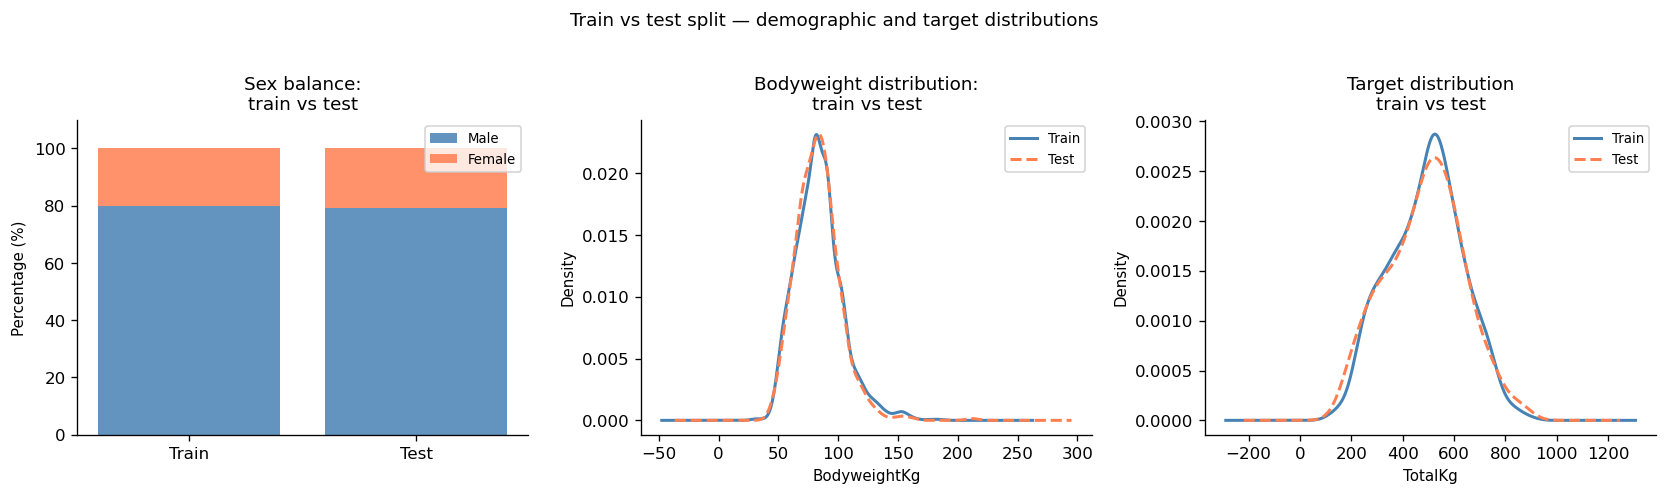

SBD


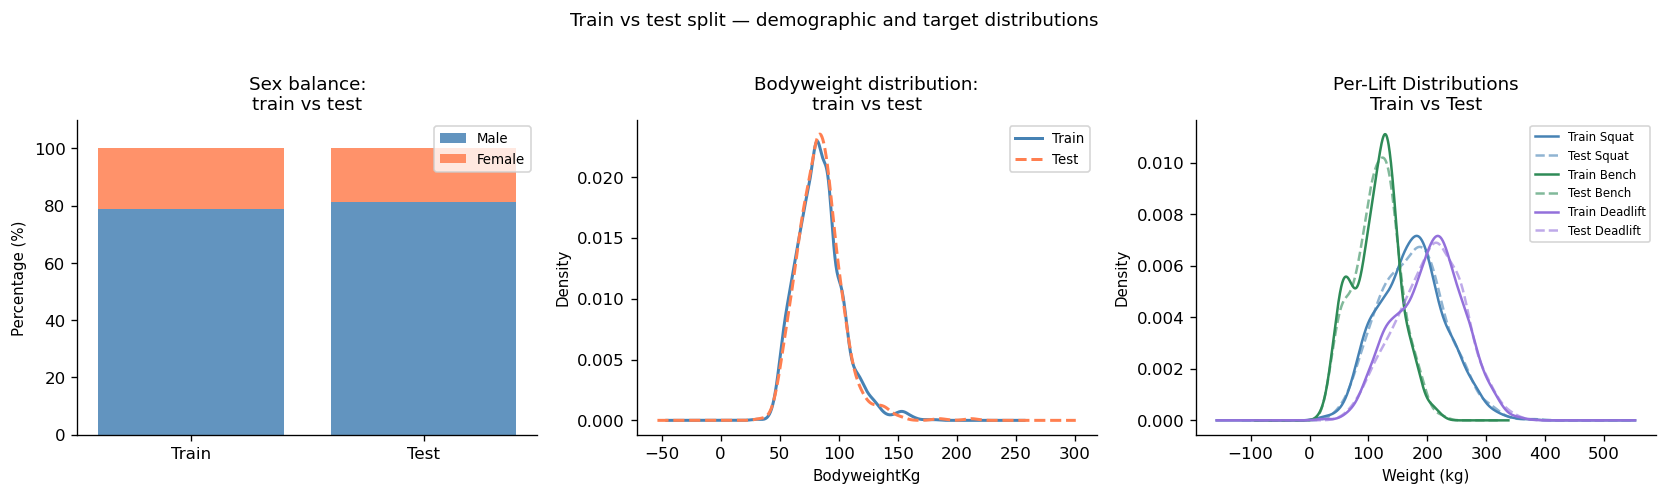

In [34]:
fig, axes = plt.subplots(1, 3, figsize = (14, 4))

print(bsep)
print('Total')
print(bsep) 

# Sex balance --- Stacked Bar 
sex_data = pd.DataFrame({
    'Split': ['Train','Test'], 
    'Male': [X_tr_base_total['Sex_binary'].mean() * 100,
            X_te_base_total['Sex_binary'].mean() * 100], 
    'Female': [(1 - X_tr_base_total['Sex_binary'].mean()) * 100,
            (1 - X_te_base_total['Sex_binary'].mean()) * 100], 
})

axes[0].bar(sex_data['Split'], sex_data['Male'],
            color='steelblue', label='Male', alpha=0.85)
axes[0].bar(sex_data['Split'], sex_data['Female'],
            bottom=sex_data['Male'],
            color='coral', label='Female', alpha=0.85)
axes[0].set_ylabel('Percentage (%)')
axes[0].set_title('Sex balance:\ntrain vs test')
axes[0].legend(fontsize=8)
axes[0].set_ylim(0, 110)

# BodyweightKg distribution: overlapping KDE
train_bw_total = X_tr_base_total['BodyweightKg']
test_bw_total  = X_te_base_total['BodyweightKg']

train_bw_total.plot.kde(ax=axes[1], color='steelblue',
                  linewidth=1.8, label='Train')
test_bw_total.plot.kde(ax=axes[1],  color='coral',
                 linewidth=1.8, label='Test', linestyle='--')
axes[1].set_xlabel('BodyweightKg')
axes[1].set_title('Bodyweight distribution:\ntrain vs test')
axes[1].legend(fontsize=8)

# TotalKg distribution: overlapping KDE
train_total = Y_tr_base_total.flatten()
test_total  = Y_te_base_total.flatten()

pd.Series(train_total).plot.kde(ax=axes[2], color='steelblue',
                                 linewidth=1.8, label='Train')
pd.Series(test_total).plot.kde(ax=axes[2],  color='coral',
                                linewidth=1.8, label='Test', linestyle='--')
axes[2].set_xlabel('TotalKg')
axes[2].set_title('Target distribution\ntrain vs test')
axes[2].legend(fontsize=8)

plt.suptitle('Train vs test split — demographic and target distributions',
             fontsize=11, y=1.02)
plt.tight_layout()
plt.savefig(plots_dir / 'train_test_distributions_total.png', bbox_inches='tight')
plt.show()

print(bsep)
print('SBD')
print(bsep) 

fig, axes = plt.subplots(1, 3, figsize=(14, 4)) 

# Sex balance --- Stacked Bar 
sex_data_sdb = pd.DataFrame({
    'Split': ['Train','Test'], 
    'Male': [X_tr_base_sbd['Sex_binary'].mean() * 100,
            X_te_base_sbd['Sex_binary'].mean() * 100], 
    'Female': [(1 - X_tr_base_sbd['Sex_binary'].mean()) * 100,
            (1 - X_te_base_sbd['Sex_binary'].mean()) * 100], 
})

axes[0].bar(sex_data_sdb['Split'], sex_data_sdb['Male'],
            color='steelblue', label='Male', alpha=0.85)
axes[0].bar(sex_data_sdb['Split'], sex_data_sdb['Female'],
            bottom=sex_data_sdb['Male'],
            color='coral', label='Female', alpha=0.85)
axes[0].set_ylabel('Percentage (%)')
axes[0].set_title('Sex balance:\ntrain vs test')
axes[0].legend(fontsize=8)
axes[0].set_ylim(0, 110)

# BodyweightKg distribution: overlapping KDE
train_bw_sbd = X_tr_base_sbd['BodyweightKg']
test_bw_sbd  = X_te_base_sbd['BodyweightKg']

train_bw_sbd.plot.kde(ax=axes[1], color='steelblue',
                  linewidth=1.8, label='Train')
test_bw_sbd.plot.kde(ax=axes[1],  color='coral',
                 linewidth=1.8, label='Test', linestyle='--')
axes[1].set_xlabel('BodyweightKg')
axes[1].set_title('Bodyweight distribution:\ntrain vs test')
axes[1].legend(fontsize=8)

# TotalKg distribution: overlapping KDE
lift_names = ["Squat", "Bench", "Deadlift"]
colors = ["steelblue", "seagreen", "mediumpurple"]

for i, lift_name in enumerate(lift_names):

    train_lift_data = Y_tr_base_sbd[:, i]
    test_lift_data = Y_te_base_sbd[:, i]

    pd.Series(train_lift_data).plot.kde(
        ax=axes[2],
        color=colors[i],
        linewidth=1.5,
        label=f"Train {lift_name}",
    )

    pd.Series(test_lift_data).plot.kde(
        ax=axes[2],
        color=colors[i],
        linewidth=1.5,
        linestyle="--",
        alpha=0.6,
        label=f"Test {lift_name}",  
    )
axes[2].set_xlabel("Weight (kg)")
axes[2].set_title("Per-Lift Distributions\nTrain vs Test")
axes[2].legend(fontsize=7)

plt.suptitle('Train vs test split — demographic and target distributions',
             fontsize=11, y=1.02)
plt.tight_layout()
plt.savefig(plots_dir / 'train_test_distributions_SBD.png', bbox_inches='tight')
plt.show()

## Cell 31 — Leakage audit

Confirm no feature is a near-perfect proxy for the target. 

In [68]:
# We use the original pandas Series for Y to preserve index alignment
# Converting Y_total_base to numpy before this step would break the index alignment and produce meaningless correlations 

print('Total') 
Y_audit_total = df.loc[X_base_total.index, 'TotalKg']

audit_df_total = X_base_total.copy()
audit_df_total ['TotalKg'] = Y_audit_total.values  

raw_corr_total = audit_df_total.corr()['TotalKg'].drop('TotalKg')
abs_corr_total = raw_corr_total.abs().sort_values(ascending = False)

print(bsep) 
print('Feature correlations with TotalKg')
print(bsep) 
print(abs_corr_total.round(3).to_string())

high_corr_features = abs_corr_total[abs_corr_total > 0.85]

if len(high_corr_features) == 0:
    print('\nLeakage audit passed — no feature correlates above 0.85 with TotalKg.')
else:
    print('\nWARNING — potential leakage detected:')
    print(high_corr_features.to_string())

print('\n') 
print('SBD')

target_cols = ["Best3SquatKg", "Best3BenchKg", "Best3DeadliftKg"]
Y_audit_multi = df_complete.loc[X_base_sbd.index, target_cols]

audit_df_multi = X_base_sbd.copy()
for col in target_cols:
    audit_df_multi[col] = Y_audit_multi[col].values

corr_matrix = audit_df_multi.corr()

print("Feature correlations with targets:")
has_leakage = False

for target in target_cols:
    print(bsep) 
    print(f"Correlations with {target}:")
    print(bsep) 
    
    raw_corr = corr_matrix[target].drop(labels=target_cols, errors="ignore")
    abs_corr = raw_corr.abs().sort_values(ascending=False) 
    
    for feature, value in abs_corr.round(3).items():
        print(f"{feature:<25} {value:.3f}")
        
    high_corr = abs_corr[abs_corr > 0.85]
    if len(high_corr) > 0:
        has_leakage = True
        print(f"\nWARNING — potential leakage detected for {target}:")
        
        for feature, value in high_corr.round(3).items():
            print(f"{feature:<25} {value}")

    else:
        print(f'\nLeakage audit passed — no feature correlates above 0.85 with {target}.')

Total
Feature correlations with TotalKg
Sex_binary              0.66
BodyweightKg            0.66
Fed_Other Federations   0.09
Fed_ESDT                0.05
Fed_GPL                 0.02

Leakage audit passed — no feature correlates above 0.85 with TotalKg.


SBD
Feature correlations with targets:
Correlations with Best3SquatKg:
BodyweightKg              0.644
Sex_binary                0.592
Fed_Other Federations     0.096
Fed_ESDT                  0.038
Fed_GPL                   0.031

Leakage audit passed — no feature correlates above 0.85 with Best3SquatKg.
Correlations with Best3BenchKg:
Sex_binary                0.7
BodyweightKg              0.654
Fed_Other Federations     0.063
Fed_GPL                   0.031
Fed_ESDT                  0.003

Leakage audit passed — no feature correlates above 0.85 with Best3BenchKg.
Correlations with Best3DeadliftKg:
Sex_binary                0.656
BodyweightKg              0.613
Fed_Other Federations     0.083
Fed_ESDT                  0.054
Fed_GP

## Cell 32 — Condition number check

In [71]:
X_total_full_scaled = np.vstack([X_tr_base_total_s, X_te_base_total_s])

n_nan_total = np.isnan(X_total_full_scaled).sum() 
n_inf_total = np.isinf(X_total_full_scaled).sum() 
print(f"NaN values in X_total_full_scaled:      {n_nan_total}")
print(f"Infinite values in X_total_full_scaled: {n_inf_total}")

if n_nan_total > 0 or n_inf_total > 0: 
    print("Cannot produce a condition number; we have to fix null and infinite values first") 
else: 
    cols_total_std = X_total_full_scaled.std(axis = 0) 
    zero_total_var_cols = np.where(cols_total_std == 0)[0] 

    if len(zero_total_var_cols) > 0: 
        print(f"Zero-variance columns at indices: {zero_total_var_cols}") 
    else: 
        print("No zero-variance columns found") 

NaN values in X_total_full_scaled:      0
Infinite values in X_total_full_scaled: 0
No zero-variance columns found


# PHASE 3 - CLASSICAL REGRESSION

## Cell 27 — Create output folder and define helper functions

Helper functions are defined once here and re-used in various cells. Keeping them in one place makes it easier to verify their correctness. 

In [36]:
plots_dir_p3 = Path('plots/phase3') 
plots_dir_p3.mkdir(parents=True, exist_ok=True)

print(f"Plot output folder: {plots_dir_p3.resolve()}") 

Plot output folder: /Users/kostasrigatos/anaconda_projects/a4e323e8-c04c-45ae-b8e4-06f7777a6bf4/plots/phase3


In [37]:
def mat_multiply(X, W):
    """Matrix multiplication of X and W to produce predictions""" 
    mat_mul_aux = X @ W
    return mat_mul_aux   

def rmse_per_target(Y_true, Y_pred): 
    """
    Compute the RMSE for each target column independently
    Returns an array of shape (k,) with k: the number of targets 
    """
    rmse_aux = np.sqrt(np.mean((Y_true - Y_pred) ** 2, axis = 0)) 
    return rmse_aux 

def r2_per_target(Y_true, Y_pred): 
    """
    Compute R² for each target column independently 
    Returns an array of shape (k,) 
    """
    sum_squares_residual = np.sum((Y_true - Y_pred) ** 2, axis = 0)
    sum_squares_total = np.sum((Y_true - Y_pred.mean(axis = 0)) ** 2 , axis = 0)
    r2_aux = 1 - sum_squares_residual / sum_squares_total
    return r2_aux 

# Target name lists used throughout Phase 3
target_names_total = ['TotalKg']
target_names_sbd   = ['Best3SquatKg', 'Best3BenchKg', 'Best3DeadliftKg']
all_targets_list   = target_names_total + target_names_sbd

## Cell 28 — OLS from scratch: normal equation

OLS minimizes the sum of squared residuals:
   L(W) = ||XW - Y||²

Setting the gradient to zero gives the normal equation:
   XᵀXW = XᵀY  →  W = (XᵀX)⁻¹XᵀY

 We use np.linalg.lstsq rather than explicit matrix inversion.
 lstsq uses SVD internally and is numerically stable even when
 XᵀX is nearly singular.

In [38]:
def ols_fit(X, Y): 
    """
    Fit the OLS via the normal equation using SVD-based least squares 
    X: (n, p) with the bias column already prepended 
    Y: (n, k) works for single- and multi-output targets 
    Returns W: (p, k) 
    """ 
    W, _, _, _ = np.linalg.lstsq(X, Y, rcond=None)
    return W 

# Fit OLS on TotalKg (full cohort, base features)
W_ols_total     = ols_fit(X_tr_base_b, Y_tr_base)
Y_pred_ols_tr   = predict(X_tr_base_b, W_ols_total)
Y_pred_ols_te   = predict(X_te_base_b, W_ols_total)

# Fit OLS on SBD targets (SBD cohort, base features)
W_ols_sbd       = ols_fit(X_tr_sbd_b, Y_tr_sbd)
Y_pred_ols_sbd_tr = predict(X_tr_sbd_b, W_ols_sbd)
Y_pred_ols_sbd_te = predict(X_te_sbd_b, W_ols_sbd)

# Fit OLS on TotalKg with age-augmented features
W_ols_age       = ols_fit(X_tr_age_b, Y_tr_age)
Y_pred_ols_age_te = predict(X_te_age_b, W_ols_age)

# Store OLS RMSE for later comparison tables
ols_rmse_total    = rmse_per_target(Y_te_base, Y_pred_ols_te)[0]
ols_rmse_sbd      = rmse_per_target(Y_te_sbd,  Y_pred_ols_sbd_te)
ols_rmse_age      = rmse_per_target(Y_te_age,  Y_pred_ols_age_te)[0]

ols_rmse_lookup = {
    'TotalKg':          ols_rmse_total,
    'TotalKg (+ Age)':  ols_rmse_age,
    'Best3SquatKg':     ols_rmse_sbd[0],
    'Best3BenchKg':     ols_rmse_sbd[1],
    'Best3DeadliftKg':  ols_rmse_sbd[2],
}

print('── OLS from scratch — test performance ───────────')
print(f"{'Target':<26} {'RMSE (kg)':>10} {'R²':>8}")
print('─' * 48)

# TotalKg base
rmse_val = rmse_per_target(Y_te_base, Y_pred_ols_te)[0]
r2_val   = r2_per_target(Y_te_base, Y_pred_ols_te)[0]
print(f"  {'TotalKg (base)':<24} {rmse_val:>10.2f} {r2_val:>8.3f}")

# TotalKg with Age
rmse_val = rmse_per_target(Y_te_age, Y_pred_ols_age_te)[0]
r2_val   = r2_per_target(Y_te_age, Y_pred_ols_age_te)[0]
print(f"  {'TotalKg (+ Age)':<24} {rmse_val:>10.2f} {r2_val:>8.3f}")

# SBD targets
for i, target in enumerate(target_names_sbd):
    rmse_val = rmse_per_target(Y_te_sbd, Y_pred_ols_sbd_te)[i]
    r2_val   = r2_per_target(Y_te_sbd, Y_pred_ols_sbd_te)[i]
    print(f"  {target:<24} {rmse_val:>10.2f} {r2_val:>8.3f}")

NameError: name 'X_tr_base_b' is not defined